In [1]:
#MakeMore Part3开启！
#这一部分和part2那样新开一个notebook不太一样，andrej会直接在part2的基础上继续添加东西
#我们在前面三个部分已经完整学习了神经网络的结构，而我们后面的目标就是优化他们
#直接开始吧

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline
#环境导入，和之前的环境是一样的，前两行是torch，后两行是画图工具

In [3]:
words=open("names.txt","r").read().splitlines()
words[:3]
#还是一样导入words

['emma', 'olivia', 'ava']

In [4]:
chars=sorted(list(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos={i:s for s,i in stoi.items()}
print(itos)
vocab_size=len(itos)
#还是一样建立字符数字表
#只不过直接生成好vocab_size

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
#构建训练集，验证集，测试集
#直接复制过来就好
block_size=3

def build_dataset(words,block_size):#依据words构建数据集的函数
  X, Y = [], []
  for w in words:

    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)  
      context = context[1:] + [ix] 

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)#打印数据集的大小
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1],block_size)#0%~80%
Xdev, Ydev = build_dataset(words[n1:n2],block_size)#80%~90%
Xte, Yte = build_dataset(words[n2:],block_size)#90~100%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [6]:
#先生成神经网络
g = torch.Generator().manual_seed(2147483647)

#旋钮
n_embd=10
n_hidden=200

#超参数
C = torch.randn((vocab_size, n_embd), generator=g)#嵌入层
W1 = torch.randn((block_size*n_embd,n_hidden), generator=g)#缩小到200个
b1 = torch.randn(n_hidden,generator=g)#隐藏层
W2 = torch.randn((n_hidden, vocab_size), generator=g)#激活层
b2 = torch.randn(vocab_size, generator=g)#激活层

parameters = [C, W1, b1, W2, b2]#所有的总参数，用于后续的梯度清除
print(f"总参数量：{sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad=True

总参数量：11897


In [7]:
#一样复制过来，稍微调整下参数位置就可以了
max_steps=200000
batch_size=32

lossi=[]

#训练
for i in range(max_steps):
    
    #前向传播
    ix=torch.randint(0,Xtr.shape[0],(batch_size,),generator=g)
    Xb,Yb=Xtr[ix],Ytr[ix]
    
    emb = C[Xb]
    embcat=emb.view(batch_size, block_size*n_embd)
    hpreact=embcat@ W1 + b1
    h = torch.tanh(hpreact) # (32, 100)
    logits = h @ W2 + b2 
    loss=F.cross_entropy(logits,Yb)
    
    #清空梯度
    for p in parameters:
        p.grad=None
    
    #反向传播
    loss.backward()

    #更新梯度
    lr=0.1 if i<(max_steps/2) else 0.01
    for p in parameters:
        p.data+=-lr*p.grad

    if i%10000==0:
        print(f"{i:7d}/{max_steps:7d}:{loss.item():.4f}")
    #存储参数
    lossi.append(loss.log10().item())

      0/ 200000:27.8817
  10000/ 200000:2.8138
  20000/ 200000:2.5218
  30000/ 200000:2.7874
  40000/ 200000:2.0334
  50000/ 200000:2.6237
  60000/ 200000:2.3289
  70000/ 200000:2.0826
  80000/ 200000:2.2784
  90000/ 200000:2.2252
 100000/ 200000:2.0428
 110000/ 200000:2.3121
 120000/ 200000:2.0570
 130000/ 200000:2.4546
 140000/ 200000:2.2233
 150000/ 200000:2.1551
 160000/ 200000:2.0597
 170000/ 200000:1.7981
 180000/ 200000:2.0194
 190000/ 200000:1.7459


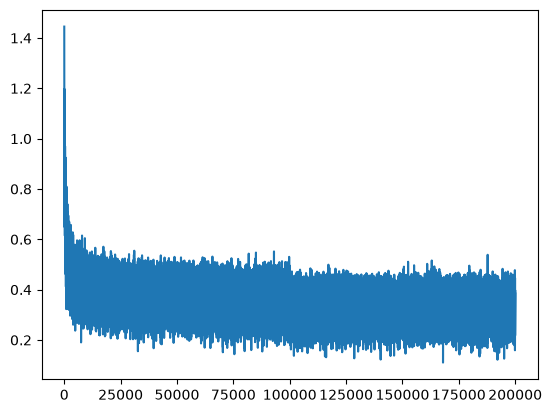

In [8]:
plt.plot(lossi)

In [9]:
@torch.no_grad() #关掉grad,评估的时候不需要反向传播
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]#用传入的split进行查表
    
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')


train 2.1267659664154053
val 2.1697638034820557


In [10]:
#采样部分，和之前是一样的，只不过我们不用多层神经网络
g = torch.Generator().manual_seed(2147483647+10)#换个种子

for i in range(20):#生成20个名字
    context=[0]*block_size#上下文。由于我们所有名字的开头全部都是一串点，所以我们可以直接用这个
    out=[]#输出

    while True:#用循环来生成姓名，直到出现'.'
        emb = C[torch.tensor([context])] 
        embcat = emb.view(1, -1) 
        h = torch.tanh(embcat @ W1 + b1) 
        logits = h @ W2 + b2 # (N, vocab_size)
        probs=F.softmax(logits,dim=1)#loss的计算用的是cross_entropy，现在用softmax计算probs
        ix=torch.multinomial(probs,num_samples=1,generator=g).item()#根据概率输出词汇
        context=context[1:]+[ix]
        out.append(itos[ix])
        if ix==0:
            break
    print(''.join(s for s in out))

carlah.
amorie.
khirmin.
rey.
cassanden.
jazhubedah.
sart.
kaeli.
nellara.
chaiir.
kaleigh.
ham.
jore.
quint.
salin.
alianni.
wazthoniearyxi.
jace.
pirran.
eddeci.


In [11]:
#我们现在要改进我们的神经网络
#所以第一步就是：先看看他有什么问题
#首先我们会发现：我们一开始的loss出奇的高
#我们来预估一下如果一个均匀分布的loss是多少
#loss是概率的负对数似然
#所以就是
-torch.tensor(1.0/27.0).log()

tensor(3.2958)

In [12]:
#所以其实我们的loss一开始能到20多是完全没有道理的
#很可能是因为我们的一开始随机出来的参数导致了非常大的偏差
#我们用一个直观的例子
logits=torch.tensor([0.0,0.0,0.0,0.0])
probs=torch.softmax(logits,dim=0)
loss=-(probs[2].log())
probs,loss

(tensor([0.2500, 0.2500, 0.2500, 0.2500]), tensor(1.3863))

In [13]:
#这就是均匀分布出来的loss，当我们调大某个值

#调大错误答案
logits=torch.tensor([0.0,5.0,0.0,0.0])
probs=torch.softmax(logits,dim=0)
loss=-(probs[2].log())
print("错误情况：",loss)

#调大正确答案
logits=torch.tensor([0.0,0.0,5.0,0.0])
probs=torch.softmax(logits,dim=0)
loss=-(probs[2].log())
print("正确情况：",loss)

错误情况： tensor(5.0200)
正确情况： tensor(0.0200)


In [14]:
#可以看到差距非常巨大

In [15]:
#所以我们回过头来看看一开始为什么会出现这种情况
#先生成神经网络
g = torch.Generator().manual_seed(2147483647)

#旋钮
n_embd=10
n_hidden=200

#超参数
C = torch.randn((vocab_size, n_embd), generator=g)#嵌入层
W1 = torch.randn((block_size*n_embd,n_hidden), generator=g)#缩小到200个
b1 = torch.randn(n_hidden,generator=g)#隐藏层
W2 = torch.randn((n_hidden, vocab_size), generator=g)#激活层
b2 = torch.randn(vocab_size, generator=g)#激活层

parameters = [C, W1, b1, W2, b2]#所有的总参数，用于后续的梯度清除
print(f"总参数量：{sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad=True

#一样复制过来，稍微调整下参数位置就可以了
max_steps=200000
batch_size=32

lossi=[]

#训练
for i in range(max_steps):
    
    #前向传播
    ix=torch.randint(0,Xtr.shape[0],(batch_size,),generator=g)
    Xb,Yb=Xtr[ix],Ytr[ix]
    
    emb = C[Xb]
    embcat=emb.view(batch_size, block_size*n_embd)
    hpreact=embcat@ W1 + b1
    h = torch.tanh(hpreact) # (32, 100)
    logits = h @ W2 + b2 
    loss=F.cross_entropy(logits,Yb)
    
    #清空梯度
    for p in parameters:
        p.grad=None
    
    #反向传播
    loss.backward()

    #更新梯度
    lr=0.1 if i<(max_steps/2) else 0.01
    for p in parameters:
        p.data+=-lr*p.grad

    if i%10000==0:
        print(f"{i:7d}/{max_steps:7d}:{loss.item():.4f}")
    #存储参数
    lossi.append(loss.log10().item())

    break#直接break去观察logits

总参数量：11897
      0/ 200000:27.8817


In [16]:
#21，非常高
#我们来观察下具体的logits
logits[0]

tensor([ -2.3527,  36.4366, -10.7306,   5.7165,  18.6409, -11.6998,  -2.1991,
          1.8535,  10.9996,  10.6730,  12.3507, -10.3809,   4.7243, -24.4257,
         -8.5909,   1.9024, -12.2744, -12.4751, -23.2778,  -2.0163,  25.8767,
         14.2108,  17.7691, -10.9204, -20.7335,   6.4560,  11.1615],
       grad_fn=<SelectBackward0>)

In [17]:
#可以看到我们会出现一些非常大的数字，甚至有不少超过10的，那么我们的loss直接打到20多的数值也就不奇怪了

In [18]:
#我们思考一下为什么会出现这个问题：
g = torch.Generator().manual_seed(2147483647)

#旋钮
n_embd=10
n_hidden=200

#超参数
C = torch.randn((vocab_size, n_embd), generator=g)#嵌入层
W1 = torch.randn((block_size*n_embd,n_hidden), generator=g)#缩小到200个
b1 = torch.randn(n_hidden,generator=g)#隐藏层
W2 = torch.randn((n_hidden, vocab_size), generator=g)#激活层
b2 = torch.randn(vocab_size, generator=g)#激活层

parameters = [C, W1, b1, W2, b2]#所有的总参数，用于后续的梯度清除
print(f"总参数量：{sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad=True
#这是我们的神经网络
#只有这里涉及到了randn的赋值
#我们先来看看这里会生成什么样的数值
C[0]

总参数量：11897


tensor([ 1.5674, -0.2373, -0.0274, -1.1008,  0.2859, -0.0296, -1.5471,  0.6049,
         0.0791,  0.9046], grad_fn=<SelectBackward0>)

In [19]:
#其实还好，对吧？
#这里会按照正态分布在0附近进行分布
#但是在这个过程中会涉及好几次乘法加法
#于是这种值会逐渐累加导致最后变得非常夸张
#所以我们的第一个思路就是：神经网络在初始化的时候缩放的小一些

g = torch.Generator().manual_seed(2147483647)

#旋钮
n_embd=10
n_hidden=200

#超参数
C = torch.randn((vocab_size, n_embd),          generator=g)#嵌入层
W1 = torch.randn((block_size*n_embd,n_hidden), generator=g)#隐藏层
b1 = torch.randn(n_hidden,                     generator=g)#隐藏层
W2 = torch.randn((n_hidden,vocab_size),        generator=g)*0.1#激活层
b2 = torch.randn(vocab_size,                   generator=g)*0#激活层
#我们这里给神经网络进行缩放

parameters = [C, W1, b1, W2, b2]#所有的总参数，用于后续的梯度清除
print(f"总参数量：{sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad=True

总参数量：11897


In [20]:
#一样复制过来，稍微调整下参数位置就可以了
max_steps=200000
batch_size=32

lossi=[]

#训练
for i in range(max_steps):
    
    #前向传播
    ix=torch.randint(0,Xtr.shape[0],(batch_size,),generator=g)
    Xb,Yb=Xtr[ix],Ytr[ix]
    
    emb = C[Xb]
    embcat=emb.view(batch_size, block_size*n_embd)
    hpreact=embcat@ W1 + b1
    h = torch.tanh(hpreact) # (32, 100)
    logits = h @ W2 + b2 
    loss=F.cross_entropy(logits,Yb)
    
    #清空梯度
    for p in parameters:
        p.grad=None
    
    #反向传播
    loss.backward()

    #更新梯度
    lr=0.1 if i<(max_steps/2) else 0.01
    for p in parameters:
        p.data+=-lr*p.grad

    if i%10000==0:
        print(f"{i:7d}/{max_steps:7d}:{loss.item():.4f}")
    #存储参数
    lossi.append(loss.log10().item())

      0/ 200000:4.2326
  10000/ 200000:2.1403
  20000/ 200000:2.4720
  30000/ 200000:2.5577
  40000/ 200000:2.0154
  50000/ 200000:2.4307
  60000/ 200000:2.3385
  70000/ 200000:2.0680
  80000/ 200000:2.2665
  90000/ 200000:2.1172
 100000/ 200000:1.9299
 110000/ 200000:2.0630
 120000/ 200000:1.8901
 130000/ 200000:2.3980
 140000/ 200000:2.2826
 150000/ 200000:2.1250
 160000/ 200000:1.8469
 170000/ 200000:1.7627
 180000/ 200000:1.9119
 190000/ 200000:1.8235


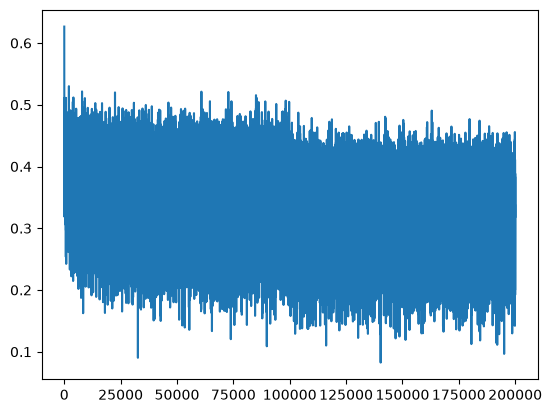

In [21]:
plt.plot(lossi)

In [22]:
@torch.no_grad() #关掉grad,评估的时候不需要反向传播
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]#用传入的split进行查表
    
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0681495666503906
val 2.132511854171753


In [23]:
#loss有微弱的下降
#并且我们的训练曲线不再是“曲棍球棒”形状了
#也就是说我们跳过了一开始loss急剧下降的压缩阶段

In [24]:
#好的接下来，优化完了这个神经网络，我们可以再看一下更深层的东西：h
#我们把这个h单独拎出来
g = torch.Generator().manual_seed(2147483647)

#旋钮
n_embd=10
n_hidden=200

#超参数
C = torch.randn((vocab_size, n_embd),          generator=g)#嵌入层
W1 = torch.randn((block_size*n_embd,n_hidden), generator=g)#隐藏层
b1 = torch.randn(n_hidden,                     generator=g)#隐藏层
W2 = torch.randn((n_hidden,vocab_size),        generator=g)*0.1#激活层
b2 = torch.randn(vocab_size,                   generator=g)*0#激活层
#我们这里给神经网络进行缩放

parameters = [C, W1, b1, W2, b2]#所有的总参数，用于后续的梯度清除
print(f"总参数量：{sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad=True

max_steps=200000
batch_size=32

lossi=[]

#训练
for i in range(max_steps):
    
    #前向传播
    ix=torch.randint(0,Xtr.shape[0],(batch_size,),generator=g)
    Xb,Yb=Xtr[ix],Ytr[ix]
    
    emb = C[Xb]
    embcat=emb.view(batch_size, block_size*n_embd)
    hpreact=embcat@ W1 + b1
    h = torch.tanh(hpreact) # (32, 100)
    logits = h @ W2 + b2 
    loss=F.cross_entropy(logits,Yb)
    
    #清空梯度
    for p in parameters:
        p.grad=None
    
    #反向传播
    loss.backward()

    #更新梯度
    lr=0.1 if i<(max_steps/2) else 0.01
    for p in parameters:
        p.data+=-lr*p.grad

    if i%10000==0:
        print(f"{i:7d}/{max_steps:7d}:{loss.item():.4f}")
    #存储参数
    lossi.append(loss.log10().item())
    break

h

总参数量：11897
      0/ 200000:4.2326


tensor([[ 0.8100, -0.8997, -0.9993,  ..., -0.9097, -1.0000,  1.0000],
        [-1.0000, -0.9571, -0.7145,  ...,  0.4898,  0.9090,  0.9937],
        [ 0.9983, -0.3340,  1.0000,  ...,  0.9443,  0.9905,  1.0000],
        ...,
        [-1.0000,  0.9604, -0.1418,  ..., -0.1266,  1.0000,  1.0000],
        [-1.0000, -0.4385, -0.8882,  ..., -0.3316,  0.9995,  1.0000],
        [-1.0000,  0.9604, -0.1418,  ..., -0.1266,  1.0000,  1.0000]],
       grad_fn=<TanhBackward0>)

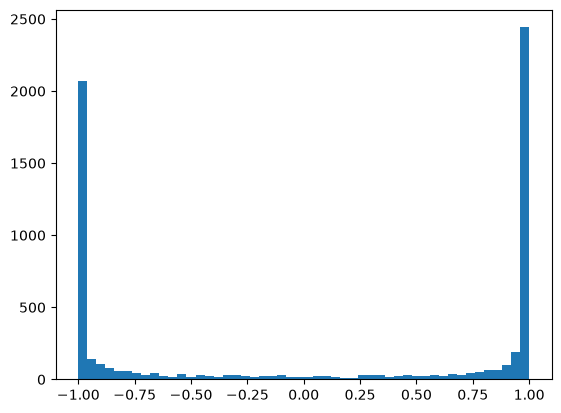

In [25]:
#我们会发现一个问题：就是h里有很多的值是1或-1或者非常接近这两个值
plt.hist(h.view(-1).tolist(),50);#这个可以生成h的直方图

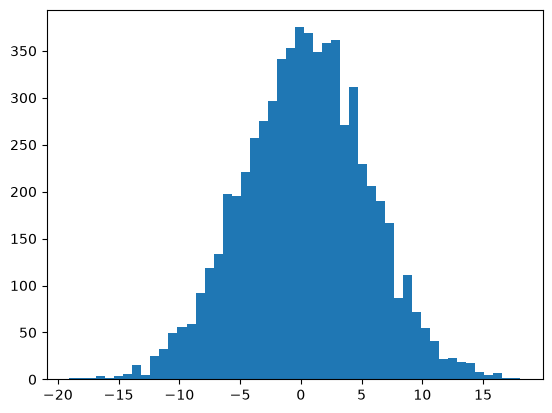

In [26]:
#这个是不是很直观，h的分布非常不健康
#所以我们来看看k接收的输入hpreact长什么样
plt.hist(hpreact.view(-1).tolist(),50);

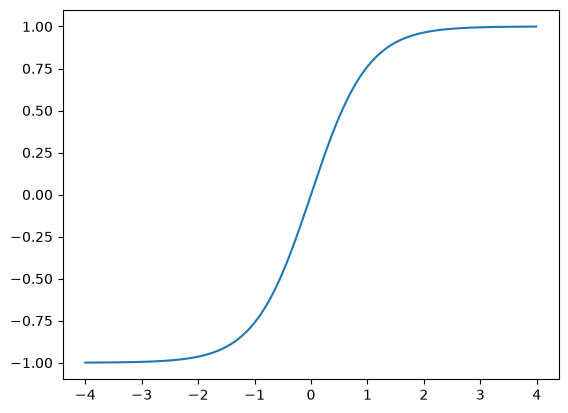

In [27]:
#其实还好，是吧？基本符合正态分布，因为我们之前就是用正态分布生成的神经网络
#但是hpreact到h的计算是tanh
#还记得tanh长什么样子吗？
import math
ii=[]
tanh=[]
for i in range(-400,400,1):
    tanh.append(math.tanh(i/100))
    ii.append(i/100)

plt.plot(ii,tanh)

In [28]:
#这个是tanh的函数曲线
#我们可以发现：大概在3左右tanh就已经非常逼近1了
#所以当h接收了hpreact之后就非常容易出现这种数值过大或者过小导致精度丢失的问题

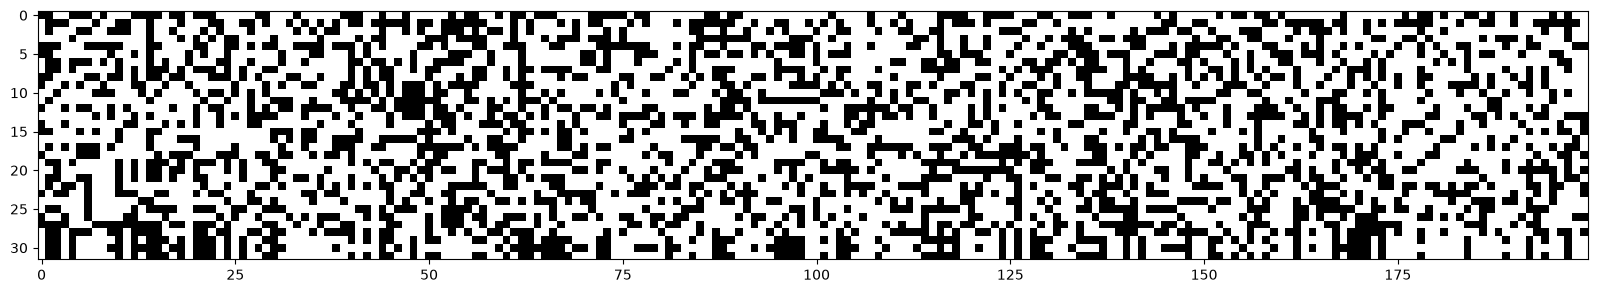

In [29]:
#那么这个会有什么问题呢？
#回忆一下micrograd
#我们的调整方式是梯度下降法。
#但是我们来观察一下这个tanh函数接近1之后的梯度长什么样：
#几乎是0
#也就是说：当我们的h趋近于1或者-1的时候：我们的grad调不动他了
#甚至可能会出现grad卡死的情况：因为精度不够导致梯度直接被看成了0
#我们来观察一下有多少的h处于这种极端区间（绝对值>0.99）
plt.figure(figsize=(20,10))
plt.imshow(h.abs()>0.99,cmap="gray",interpolation='nearest')#在这里符合最前面那个标准的会显示为白色

In [30]:
#可以发现几乎一大半的参数都显示为超过0.99
#这就是大麻烦：这种神经元无法进行梯度更新，也就是说会变成“死亡神经元”
#这种神经元学不到东西 
#同时这种情况也很可能出现在训练过程中：
#因为训练过程如果步长设置的太大的话，可能会导致我们的h一脚直接踏到了“死亡区”
#这就是训练中的“脑损伤”
#有时候出现这种情况就会发现有的神经元从来没有被激活过，也就是再也不该变了
#这个时候这个神经元就“死亡”了

#所以这样看其实有个很简单的方法：我们直接把之前的参数初始值再调低一点就可以了


g = torch.Generator().manual_seed(2147483647)

#旋钮
n_embd=10
n_hidden=200

#超参数
C = torch.randn((vocab_size, n_embd),          generator=g)          #嵌入层
W1 = torch.randn((block_size*n_embd,n_hidden), generator=g)*0.2      #隐藏层
b1 = torch.randn(n_hidden,                     generator=g)*0.01     #隐藏层
W2 = torch.randn((n_hidden,vocab_size),        generator=g)*0.01     #激活层
b2 = torch.randn(vocab_size,                   generator=g)*0        #激活层
#我们这里给神经网络进行缩放

parameters = [C, W1, b1, W2, b2]#所有的总参数，用于后续的梯度清除
print(f"总参数量：{sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad=True

max_steps=200000
batch_size=32

lossi=[]

#训练
for i in range(max_steps):
    
    #前向传播
    ix=torch.randint(0,Xtr.shape[0],(batch_size,),generator=g)
    Xb,Yb=Xtr[ix],Ytr[ix]
    
    emb = C[Xb]
    embcat=emb.view(batch_size, block_size*n_embd)
    hpreact=embcat@ W1 + b1
    h = torch.tanh(hpreact) # (32, 100)
    logits = h @ W2 + b2 
    loss=F.cross_entropy(logits,Yb)
    
    #清空梯度
    for p in parameters:
        p.grad=None
    
    #反向传播
    loss.backward()

    #更新梯度
    lr=0.1 if i<(max_steps/2) else 0.01
    for p in parameters:
        p.data+=-lr*p.grad

    if i%10000==0:
        print(f"{i:7d}/{max_steps:7d}:{loss.item():.4f}")
    #存储参数
    lossi.append(loss.log10().item())
    break

h

总参数量：11897
      0/ 200000:3.3135


tensor([[ 0.5503, -0.1064, -0.6658,  ..., -0.3477, -0.9756,  0.8880],
        [-0.9081, -0.1924, -0.1833,  ...,  0.0494,  0.4942,  0.4397],
        [ 0.8016,  0.1173,  0.8237,  ...,  0.2890,  0.6476,  0.8827],
        ...,
        [-0.9190,  0.5208, -0.0346,  ..., -0.0830,  0.8660,  0.8849],
        [-0.9362,  0.0930, -0.2810,  ..., -0.1260,  0.7874,  0.9102],
        [-0.9190,  0.5208, -0.0346,  ..., -0.0830,  0.8660,  0.8849]],
       grad_fn=<TanhBackward0>)

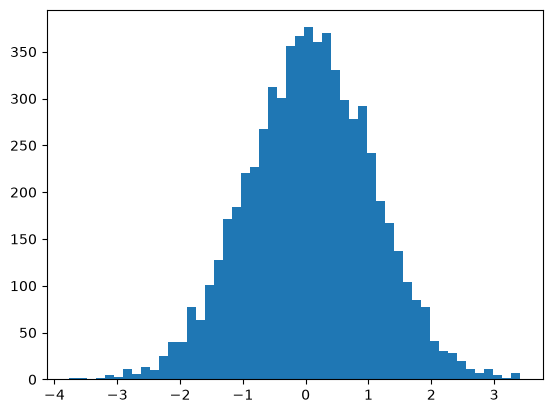

In [31]:
#这样是不是好了很多？
plt.hist(hpreact.view(-1).tolist(),50);

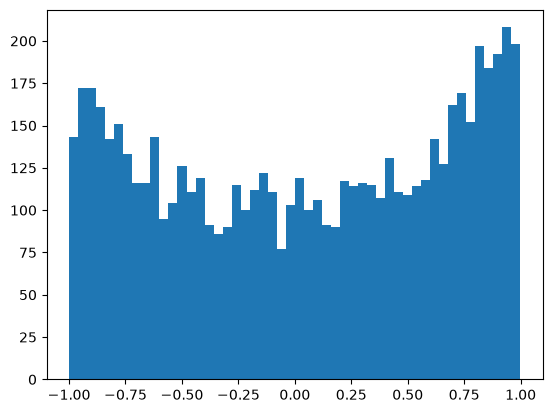

In [32]:
plt.hist(h.view(-1).tolist(),50);

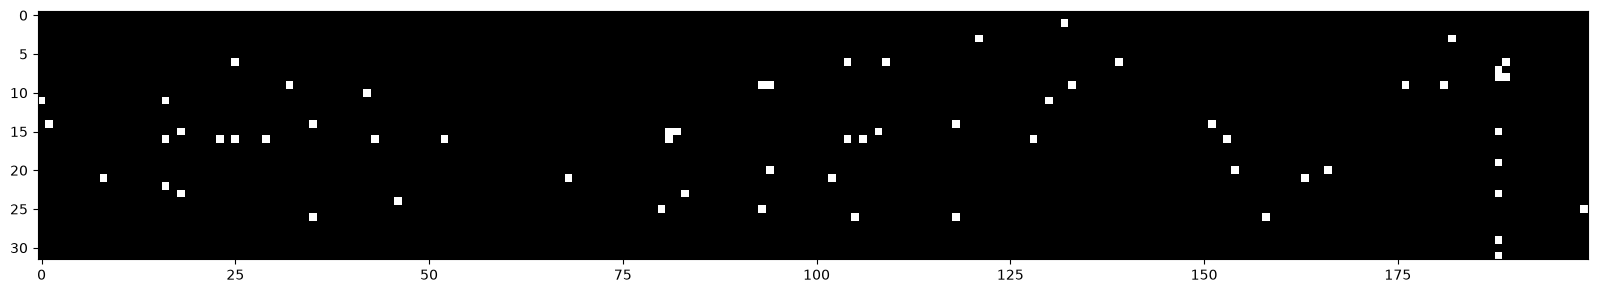

In [33]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs()>0.99,cmap="gray",interpolation='nearest')

In [34]:
#可以看到现在之后很少的白点了，而且h的分布比较均匀了

In [35]:
#现在来完整训练
g = torch.Generator().manual_seed(2147483647)

#旋钮
n_embd=10
n_hidden=200

#超参数
C = torch.randn((vocab_size, n_embd),          generator=g)          #嵌入层
W1 = torch.randn((block_size*n_embd,n_hidden), generator=g)*0.2      #隐藏层
b1 = torch.randn(n_hidden,                     generator=g)*0.01     #隐藏层
W2 = torch.randn((n_hidden,vocab_size),        generator=g)*0.01     #激活层
b2 = torch.randn(vocab_size,                   generator=g)*0        #激活层
#我们这里给神经网络进行缩放

parameters = [C, W1, b1, W2, b2]#所有的总参数，用于后续的梯度清除
print(f"总参数量：{sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad=True

max_steps=200000
batch_size=32

lossi=[]

#训练
for i in range(max_steps):
    
    #前向传播
    ix=torch.randint(0,Xtr.shape[0],(batch_size,),generator=g)
    Xb,Yb=Xtr[ix],Ytr[ix]
    
    emb = C[Xb]
    embcat=emb.view(batch_size, block_size*n_embd)
    hpreact=embcat@ W1 + b1
    h = torch.tanh(hpreact) # (32, 100)
    logits = h @ W2 + b2 
    loss=F.cross_entropy(logits,Yb)
    
    #清空梯度
    for p in parameters:
        p.grad=None
    
    #反向传播
    loss.backward()

    #更新梯度
    lr=0.1 if i<(max_steps/2) else 0.01
    for p in parameters:
        p.data+=-lr*p.grad

    if i%10000==0:
        print(f"{i:7d}/{max_steps:7d}:{loss.item():.4f}")
    #存储参数
    lossi.append(loss.log10().item())

总参数量：11897
      0/ 200000:3.3135
  10000/ 200000:2.1648
  20000/ 200000:2.3061
  30000/ 200000:2.4541
  40000/ 200000:1.9787
  50000/ 200000:2.2930
  60000/ 200000:2.4232
  70000/ 200000:2.0680
  80000/ 200000:2.3095
  90000/ 200000:2.1207
 100000/ 200000:1.8269
 110000/ 200000:2.2045
 120000/ 200000:1.9797
 130000/ 200000:2.3946
 140000/ 200000:2.1000
 150000/ 200000:2.1948
 160000/ 200000:1.8619
 170000/ 200000:1.7809
 180000/ 200000:1.9673
 190000/ 200000:1.8295


In [36]:
#重新评估一下
@torch.no_grad() #关掉grad,评估的时候不需要反向传播
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]#用传入的split进行查表
    
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0355966091156006
val 2.1026782989501953


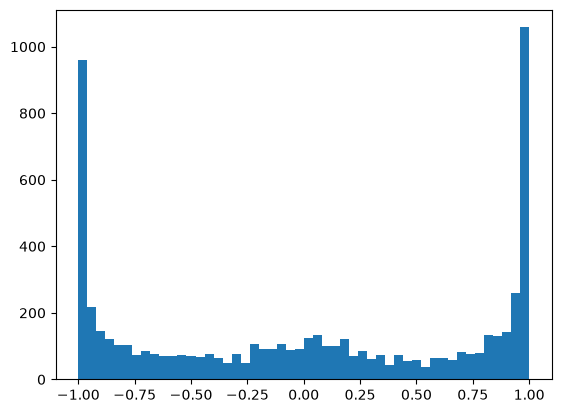

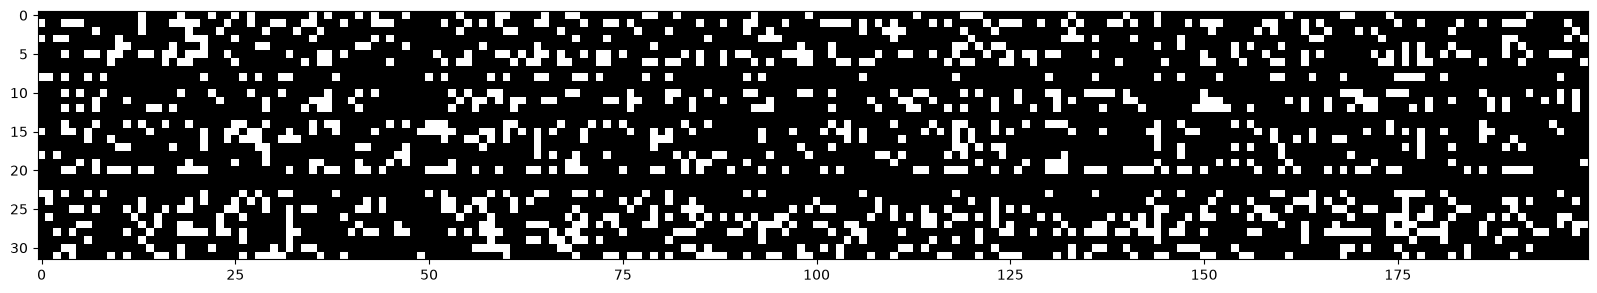

In [37]:
#可以看到loss又下降了一点
#我们看看训练后的h长什么样
plt.hist(h.view(-1).tolist(),50);
plt.figure(figsize=(20,10))
plt.imshow(h.abs()>0.99,cmap="gray",interpolation='nearest')

In [38]:
#可以看到还是会有有的h会损伤，但是明显比之前初始化时候出现的大片白色好多了
#可能有同学会觉得我们的优化非常简单，但事实上是因为我们的模型非常简单，导致一开始这些问题就不是很严重
#那我们现在来试试看我们上次写的那个多层的模型

总参数量：180707
训练进度：      0/ 100000():3.7132
训练进度：  10000/ 100000():2.2334
训练进度：  20000/ 100000():1.8644
训练进度：  30000/ 100000():1.7812
训练进度：  40000/ 100000():1.7505
训练进度：  50000/ 100000():2.1965
训练进度：  60000/ 100000():2.0252
训练进度：  70000/ 100000():1.8611
训练进度：  80000/ 100000():2.1808
训练进度：  90000/ 100000():2.2280
训练集loss=1.9858675003051758
验证集loss=2.097766637802124


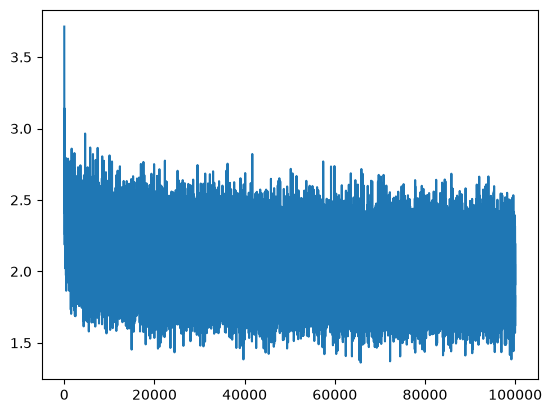

In [39]:
#训练成功
#但是loss不是太低，有很多种方面的原因
#同学可以自己试试看，调一调参数

#固定参数
vocab_size=27
g = torch.Generator().manual_seed(2147483647)

#旋钮
block_size=3
n_embd=40
n_steps=100000
batch_size=50
lr=0.03
layer_size=[block_size*n_embd,800,100,vocab_size]

Ws=[]
bs=[]

#超参数
C = torch.randn((vocab_size, n_embd), generator=g)#嵌入层

#神经网络层
for n1,n2 in zip(layer_size[:-1],layer_size[1:]):
    Ws.append(torch.randn((n1,n2), generator=g)*0.1)#优化一下
    bs.append(torch.randn(n2,generator=g)*0.01)
    
parameters = [C]+Ws+bs#所有的总参数，用于后续的梯度清除

print(f"总参数量：{sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad=True

#构建数据集
def build_dataset(words,block_size):
  X, Y = [], []
  for w in words:

    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)  
      context = context[1:] + [ix] 

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1],block_size)
Xdev, Ydev = build_dataset(words[n1:n2],block_size)
Xte, Yte = build_dataset(words[n2:],block_size)

#绘图参数
stepi=[]
lossi=[]

#训练
for i in range(n_steps):
    
    #前向传播
    ix=torch.randint(0,Xtr.shape[0],(batch_size,))
    emb = C[Xtr[ix]] 
    x = emb.view(-1, block_size * n_embd)
    for W, b in zip(Ws[:-1], bs[:-1]):
        x = torch.tanh(x @ W + b)     
    logits = x @ Ws[-1] + bs[-1]                    
    loss=F.cross_entropy(logits,Ytr[ix])
    
    #清空梯度
    for p in parameters:
        p.grad=None
    
    #反向传播
    loss.backward()

    #更新梯度
    for p in parameters:
        p.data+=-lr*p.grad

    #存储参数
    stepi.append(i)
    lossi.append(loss.item())

    if i%10000==0:
        print(f"训练进度：{i:7d}/{n_steps:7d}():{loss.item():.4f}")

emb = C[Xtr] 
x = emb.view(-1, block_size*n_embd)
for W, b in zip(Ws[:-1], bs[:-1]):
    x = torch.tanh(x @ W + b)     
logits = x @ Ws[-1] + bs[-1]               
loss=F.cross_entropy(logits,Ytr)
print(f"训练集loss={loss.item()}")


emb = C[Xdev] 
x = emb.view(-1, block_size*n_embd)
for W, b in zip(Ws[:-1], bs[:-1]):
    x = torch.tanh(x @ W + b)     
logits = x @ Ws[-1] + bs[-1]                  
loss=F.cross_entropy(logits,Ydev)
print(f"验证集loss={loss.item()}")

plt.plot(stepi,lossi)

In [40]:
#是不是非常厉害！我们之前只能到2.2左右，现在直接降到了2以下！

In [41]:
#但是我们刚刚的调试就像我们一开始去创建这个神经网络一样：纯手动，没有什么系统性
#那么怎么系统性的去优化我们的神经网络呢？
#首先，我们要分析清楚：为什么我们会出现刚刚的问题？

tensor(-0.0071) tensor(1.0046)
tensor(-0.0048) tensor(3.0733)


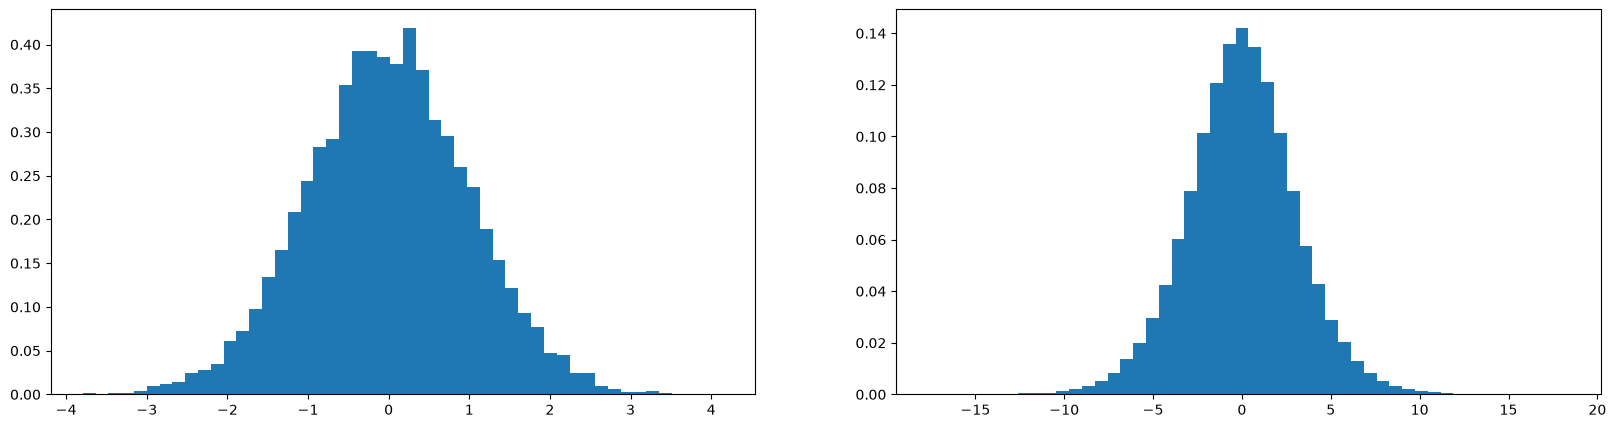

In [42]:
x=torch.randn(1000,10)
w=torch.randn(10,200)
#randn函数会生成符合高斯分布的随机数，也就是标准正态分布，均值0，标准差1
y=x@w
print(x.mean(),x.std())#std是标准差
print(y.mean(),y.std())

plt.figure(figsize=(20, 5))#创建画布，宽 20，高 5
plt.subplot(121)#1 行 2 列，第 1 个子图
plt.hist(x.view(-1).tolist(), 50, density=True);#绘制概率密度分布
plt.subplot(122)#1 行 2 列，第 2 个子图
plt.hist(y.view(-1).tolist(), 50, density=True);

tensor(0.0026) tensor(1.0021)
tensor(1.5781e-05) tensor(1.0104)


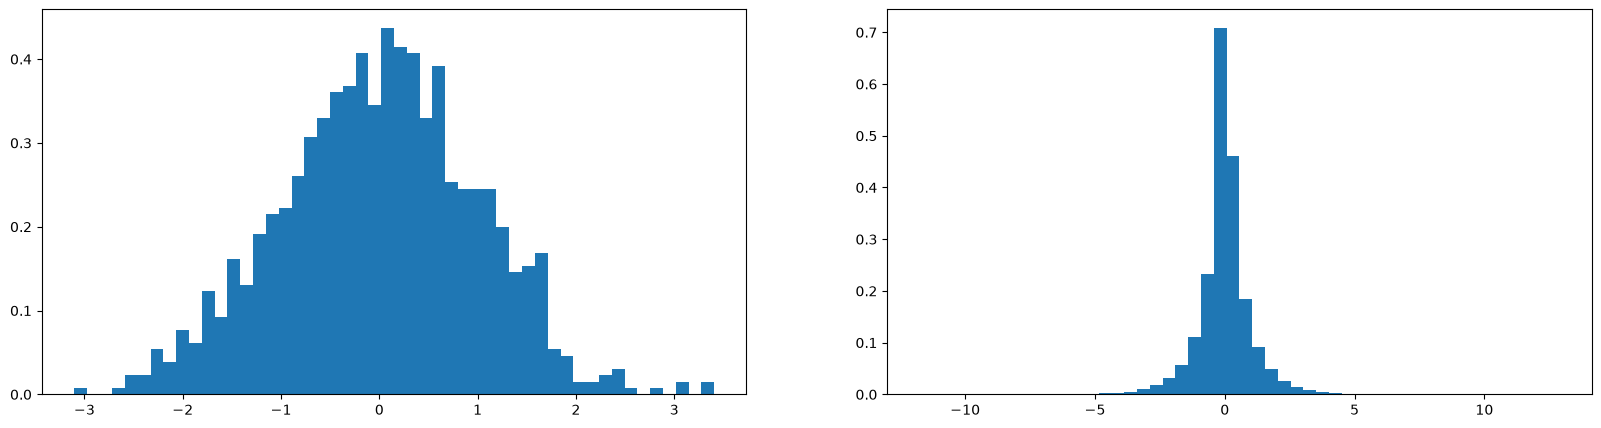

In [43]:
#我们可以发现一件事：乘积之后y的均值变化不大，但是标准差明显变大了，这就是我们的算法里多次累乘累加会导致的问题：出现大值变量
#这里的关键问题是：我们是矩阵乘法，矩阵乘法会导致其中产生加法

x=torch.randn(1000,1)
w=torch.randn(1,1000)
#randn函数会生成符合高斯分布的随机数，也就是标准正态分布，均值0，标准差1
y=x@w
print(x.mean(),x.std())#std是标准差
print(y.mean(),y.std())

plt.figure(figsize=(20, 5))#创建画布，宽 20，高 5
plt.subplot(121)#1 行 2 列，第 1 个子图
plt.hist(x.view(-1).tolist(), 50, density=True);#绘制概率密度分布
plt.subplot(122)#1 行 2 列，第 2 个子图
plt.hist(y.view(-1).tolist(), 50, density=True);

tensor(-0.0030) tensor(0.9876)
tensor(0.0041) tensor(1.0119)


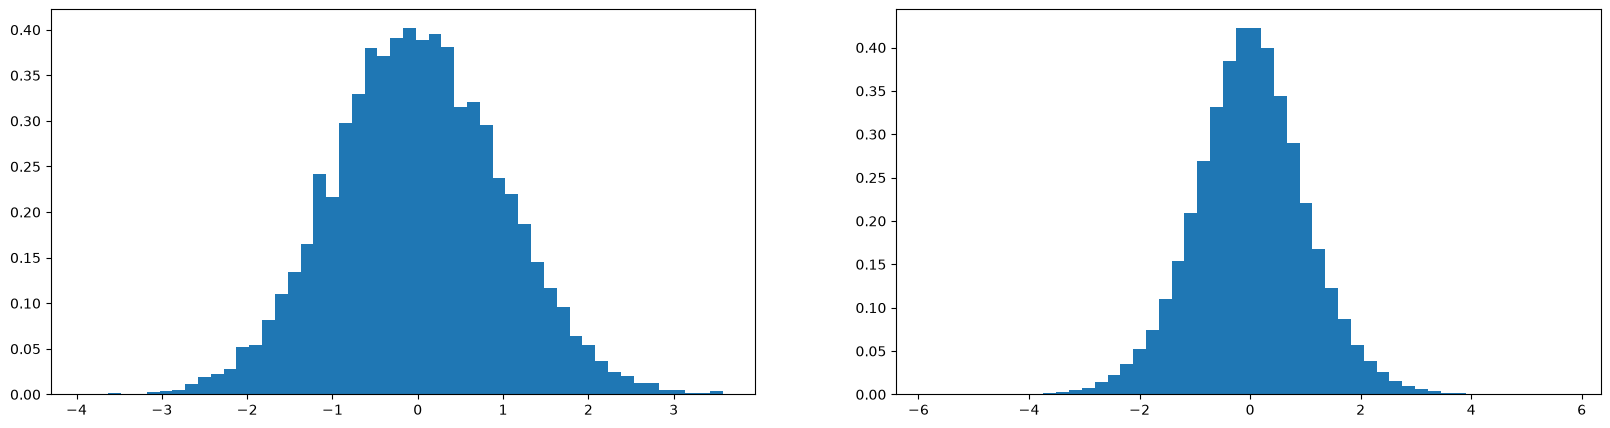

In [44]:
#这样就会发现好了非常多，因为x和w的形状是一列和一行，y的每一个元素都是一个单独的元素乘一个单独的元素
#并且我们可以发现：高斯分布的一个数乘上高斯分布的一个数出来的结果的标准差不会变
#但是我们现在需要十个数相乘之后加起来标准差还不变
#所以根据数学规则：我们需要在这个基础上去除以√10
x=torch.randn(1000,10)
w=torch.randn(10,200)/(10**0.5)
#randn函数会生成符合高斯分布的随机数，也就是标准正态分布，均值0，标准差1
y=x@w
print(x.mean(),x.std())#std是标准差
print(y.mean(),y.std())

plt.figure(figsize=(20, 5))#创建画布，宽 20，高 5
plt.subplot(121)#1 行 2 列，第 1 个子图
plt.hist(x.view(-1).tolist(), 50, density=True);#绘制概率密度分布
plt.subplot(122)#1 行 2 列，第 2 个子图
plt.hist(y.view(-1).tolist(), 50, density=True);

In [45]:
#！！！注意：刚刚出现的所有的y，都已经不是高斯分布了
#因为高斯分布的乘法不具有封闭性
#所以这里虽然看着图像还有点像高斯分布但是其实已经不是高斯分布了

In [46]:
#现在我们手动优化了这个y，但是面对非常复杂的神经网络我们怎么去优化呢？
#何恺明团队给出了一篇非常经典的论文
#《Delving Deep into Rectifiers: Surpassing Human-Level Performance on ImageNet Classification》
#这篇论文有两个重要的贡献
#第一个是关于压缩函数的
#第二个是就是关于参数初始化的
#kaiming提出了要采用零均值高斯分布
#论文原文比较复杂
#但好在这个初始化方法已经被pytorch给集成进来了
#torch.nn.init.kaiming_normal_()就可以初始化了

In [47]:
#何恺明的论文里提出了的初始化方式的作用是：让神经元的信号在传输的时候不会越来越大也不会越来越小
#比如我们刚刚的/(10**0.5)，就是在保证信号传输的时候不会越来越大
#何恺明还提出了一个变量是gain
#是因为激活函数有时候会对变量进行压缩
#代表性的就是tanh和ReLU
#这两个函数都会对把线性层的输出进行数值上的压缩
#所以我们需要去放大一点
#这一来一回一大一小，就出现了两个变量
#一中和，就可以保证神经网络不会越传越大也不会越传越小

#对于tanh函数，gain=5/3

In [48]:
#所以现在我们把这个代入到之前的东西里
#现在来完整训练
g = torch.Generator().manual_seed(2147483647)

#旋钮
n_embd=10
n_hidden=200

#超参数
C = torch.randn((vocab_size, n_embd),          generator=g)          #嵌入层
W1 = torch.randn((block_size*n_embd,n_hidden), generator=g)*(5/3)/((block_size*n_embd)**0.5)      #隐藏层
b1 = torch.randn(n_hidden,                     generator=g)*0.01     #隐藏层
W2 = torch.randn((n_hidden,vocab_size),        generator=g)*0.01     #激活层
b2 = torch.randn(vocab_size,                   generator=g)*0        #激活层
#我们这里给神经网络进行缩放

parameters = [C, W1, b1, W2, b2]#所有的总参数，用于后续的梯度清除 
print(f"总参数量：{sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad=True

max_steps=200000
batch_size=32

lossi=[]

#训练
for i in range(max_steps):
    
    #前向传播
    ix=torch.randint(0,Xtr.shape[0],(batch_size,),generator=g)
    Xb,Yb=Xtr[ix],Ytr[ix]
    
    emb = C[Xb]
    embcat=emb.view(batch_size, block_size*n_embd)
    hpreact=embcat@ W1 + b1
    h = torch.tanh(hpreact) # (32, 100)
    logits = h @ W2 + b2 
    loss=F.cross_entropy(logits,Yb)
    
    #清空梯度
    for p in parameters:
        p.grad=None
    
    #反向传播
    loss.backward()

    #更新梯度
    lr=0.1 if i<(max_steps/2) else 0.01
    for p in parameters:
        p.data+=-lr*p.grad

    if i%10000==0:
        print(f"{i:7d}/{max_steps:7d}:{loss.item():.4f}")
    #存储参数
    lossi.append(loss.log10().item())

总参数量：11897
      0/ 200000:3.3129
  10000/ 200000:2.4228
  20000/ 200000:2.3509
  30000/ 200000:2.0158
  40000/ 200000:2.0766
  50000/ 200000:2.3837
  60000/ 200000:2.2647
  70000/ 200000:2.0855
  80000/ 200000:1.9400
  90000/ 200000:2.0193
 100000/ 200000:2.4169
 110000/ 200000:2.2000
 120000/ 200000:2.0957
 130000/ 200000:2.2537
 140000/ 200000:2.0838
 150000/ 200000:2.2849
 160000/ 200000:2.0624
 170000/ 200000:2.0430
 180000/ 200000:2.2258
 190000/ 200000:1.8990


In [49]:
#重新评估一下
@torch.no_grad() #关掉grad,评估的时候不需要反向传播
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]#用传入的split进行查表
    
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')


train 2.037754774093628
val 2.1032512187957764


In [50]:
#loss差不多
#主要是因为我们的神经网络太简单了
#一旦规模逐渐大起来了，这里的参数就会非常有用
#所以现在我们不用闷头去调整参数的缩放
#而是有了一个半指导化的思路

In [51]:
#现在的深层神经网络有一个非常好用的理论：批量归一化，BatchNorm
#接下来我们来实现它

In [52]:
#首先我们关注刚刚的网络中的hpreact
#我们希望这个东西不能太小也不能太大
#太小的话tanh会退化成线性函数，失去了非线性
#太大的话tanh会饱和，梯度消失
#所以我们希望的是这个hpreact应该近似于标准正态分布

#随后论文中提出：既然我们希望这个hpreact符合标准正态分布，那我们为什么不直接归一化呢？

In [53]:
hpreact.mean(0,keepdim=True).shape,hpreact.std(0,keepdim=True).shape

(torch.Size([1, 200]), torch.Size([1, 200]))

In [54]:
#论文中提出的的方法是：hpreact减去均值之后除以std

#集体减去均值可以让均值变为0
#除以std可以让标准差变为1
#所以近似成了标准正态分布

#论文里的std会加上一个很小的值
#目的是防止出现方差是0的情况
#但那种情况属实太罕见了
#我们这里暂时不考虑

#所以现在我们把这个代入到之前的东西里
#现在来完整训练
g = torch.Generator().manual_seed(2147483647)

#旋钮
n_embd=10
n_hidden=200

#超参数
C = torch.randn((vocab_size, n_embd),          generator=g)          #嵌入层
W1 = torch.randn((block_size*n_embd,n_hidden), generator=g)*(5/3)/((block_size*n_embd)**0.5)      #隐藏层
b1 = torch.randn(n_hidden,                     generator=g)*0.01     #隐藏层
W2 = torch.randn((n_hidden,vocab_size),        generator=g)*0.01     #激活层
b2 = torch.randn(vocab_size,                   generator=g)*0        #激活层
#我们这里给神经网络进行缩放

parameters = [C, W1, b1, W2, b2]#所有的总参数，用于后续的梯度清除 
print(f"总参数量：{sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad=True

max_steps=200000
batch_size=32

lossi=[]

#训练
for i in range(max_steps):
    
    #前向传播
    ix=torch.randint(0,Xtr.shape[0],(batch_size,),generator=g)
    Xb,Yb=Xtr[ix],Ytr[ix]
    
    emb = C[Xb]
    embcat=emb.view(batch_size, block_size*n_embd)
    hpreact=embcat@ W1 + b1

    hpreact=(hpreact-hpreact.mean(0,keepdim=True))/hpreact.std(0,keepdim=True)
    
    h = torch.tanh(hpreact) # (32, 100)
    logits = h @ W2 + b2 
    loss=F.cross_entropy(logits,Yb)
    
    #清空梯度
    for p in parameters:
        p.grad=None
    
    #反向传播
    loss.backward()

    #更新梯度
    lr=0.1 if i<(max_steps/2) else 0.01
    for p in parameters:
        p.data+=-lr*p.grad

    if i%10000==0:
        print(f"{i:7d}/{max_steps:7d}:{loss.item():.4f}")
    #存储参数
    lossi.append(loss.log10().item())
    break

总参数量：11897
      0/ 200000:3.3014


In [55]:
#效果没有很好
#论文中还有一个平滑的步骤
#论文中提出的的方法是：hpreact减去均值之后除以std

#这一步非常巧妙，因为我们之前的限制过于强硬了
#我们希望初始化的时候保持标准正态分布
#但是强行地每次都标准正态分布太强硬了
#会非常大的限制神经网络的自由度
#我们希望的是让模型往这方面去靠拢，但是又不会限制他们的自由
#所以我们采用平滑策略
#具体的实现方法如下
g = torch.Generator().manual_seed(2147483647)

#旋钮
n_embd=10
n_hidden=200

#超参数
C = torch.randn((vocab_size, n_embd),          generator=g)          #嵌入层
W1 = torch.randn((block_size*n_embd,n_hidden), generator=g)*(5/3)/((block_size*n_embd)**0.5)      #隐藏层
b1 = torch.randn(n_hidden,                     generator=g)*0.01     #隐藏层
W2 = torch.randn((n_hidden,vocab_size),        generator=g)*0.01     #激活层
b2 = torch.randn(vocab_size,                   generator=g)*0        #激活层
#我们这里给神经网络进行缩放

#bn是BatchNorm的缩写
bngain=torch.ones((1,n_hidden))
#给神经网络后续控制标准差的自由
bnbias=torch.zeros((1,n_hidden))
#给神经网络后续控制均值的自由

parameters = [C, W1, b1, W2, b2]#所有的总参数，用于后续的梯度清除 
print(f"总参数量：{sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad=True

max_steps=200000
batch_size=32

lossi=[]

#训练
for i in range(max_steps):
    
    #前向传播
    ix=torch.randint(0,Xtr.shape[0],(batch_size,),generator=g)
    Xb,Yb=Xtr[ix],Ytr[ix]
    
    emb = C[Xb]
    embcat=emb.view(batch_size, block_size*n_embd)
    hpreact=embcat@ W1 + b1

    hpreact=bngain * (hpreact - hpreact.mean(0,keepdim=True)) / hpreact.std(0,keepdim=True) + bnbias
    #新增的平滑参数可以保证初始化的时候保持标准正态分布，同时通过反向传播调整参数给予模型调整的自由
    
    h = torch.tanh(hpreact) # (32, 100)
    logits = h @ W2 + b2 
    loss=F.cross_entropy(logits,Yb)
    
    #清空梯度
    for p in parameters:
        p.grad=None
    
    #反向传播
    loss.backward()

    #更新梯度
    lr=0.1 if i<(max_steps/2) else 0.01
    for p in parameters:
        p.data+=-lr*p.grad

    if i%10000==0:
        print(f"{i:7d}/{max_steps:7d}:{loss.item():.4f}")
    #存储参数
    lossi.append(loss.log10().item())

总参数量：11897
      0/ 200000:3.3014
  10000/ 200000:2.4741
  20000/ 200000:2.3700
  30000/ 200000:2.1226
  40000/ 200000:2.0765
  50000/ 200000:2.4525
  60000/ 200000:2.2495
  70000/ 200000:2.0566
  80000/ 200000:2.0036
  90000/ 200000:2.0747
 100000/ 200000:2.4734
 110000/ 200000:2.1293
 120000/ 200000:2.1174
 130000/ 200000:2.4815
 140000/ 200000:2.4186
 150000/ 200000:2.3062
 160000/ 200000:2.1342
 170000/ 200000:2.0313
 180000/ 200000:2.2986
 190000/ 200000:1.8783


train 2.0750362873077393
val 2.1144859790802


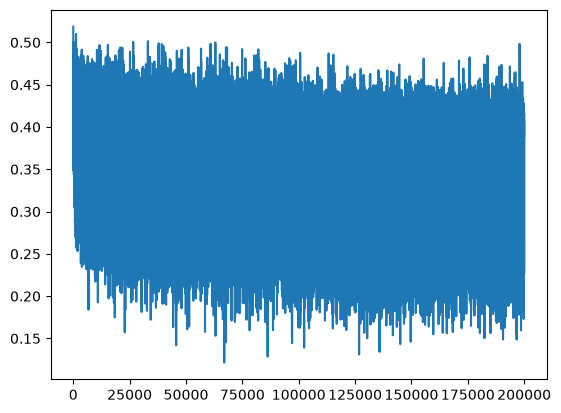

In [56]:
@torch.no_grad() #关掉grad,评估的时候不需要反向传播
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]#用传入的split进行查表
    
    emb = C[x] # (N, block_size, n_embd)
    embcat = emb.view(emb.shape[0], -1)
    hpreact=embcat@ W1 + b1
    hpreact=bngain * (hpreact - hpreact.mean(0,keepdim=True)) / hpreact.std(0,keepdim=True) + bnbias #重写测试
    h = torch.tanh(hpreact) 
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

plt.plot(lossi)

In [57]:
#可以看到我们的loss提升并不明显
#原因很简单，因为我们的隐藏层只有一层
#我们能很轻松的找出简单的标准初始化
#所以我们刚刚利用的理论并不会有很大的提升
#但是一旦神经网络变得深层复杂，涉及到了多个线性层，我们刚刚的技巧就会很有用了

In [58]:
#而且我们会发现一个很有意思的事情：
#我们刚刚BatchNorm的时候，我们的归一化方向是依据batch的
#所以刚刚我们在用这个算法的时候，我们的batch的元素之间的互有影响的
#并且这个影响会携带到反向传播

#但是这个batch是什么?
#ix=torch.randint(0,Xtr.shape[0],(batch_size,),generator=g)
#这个batch是我们随机选取的一些样本
#原本这些样本之间没有任何的关联
#只有在最后一步求loss的时候取了个均值的loss
#但是当我们使用batchnorm的时候
#这些样本在前向传播的时候就经历了一步求平均和减去平均标准差
#所以这里有个很反直觉的东西：一组batch的样本的运算过程是有关联的了

In [59]:
#这貌似不符合我们神经网络的意义，但是恰恰相反，这一步的操作极大地改善了神经网络
#为什么？
#因为这一步具有“正则化”的作用
#什么叫正则化？
#我们知道神经网络有一个问题叫过拟合
#过拟合之后神经网络就会只会做做过的题而不会做新题目
#正则化就是去避免这件事情的发生

#那为什么加入了这一步BatchNorm就可以起到正则化的作用呢？
#因为这一步有一个平均化的作用
#他会让每一个神经元也会参考到旁边神经元的分数
#所以加入了这一步会让神经网络更不容易出现饱和的问题

#更深一步的讲，batchnorm像是一种噪声
#对每个神经元来说，batch中其他的数据就是一种噪声
#这会对训练增加一种随机扰动

#为什么噪声会有帮助呢？因为噪声会让模型去真正的找“特征”
#比如我们如果想训练一个模型用于识别“猫”
#如果每一张图片我们都是橘猫
#那模型很可能把“橘色”这个属性和猫绑定
#而如果我们加入噪声：花色在变，环境在变，背景在变，光照在变
#这样的噪声会让模型对于这些无关变量的学习变弱
#从而去记忆真正独特的特性：四条腿，长尾巴，尖耳朵，长胡须等等
#这样的话模型不容易去死记硬背数据中的每一个数据，而去找真正的“特征”

#所以BatchNorm同时改善了两个方面：
#通过稳定激活分布减少饱和，使梯度更容易传播；
#通过batch统计引入随机扰动，产生类似正则化的效果，使模型更倾向学习稳定特征而不是记忆训练数据。

train 2.0750362873077393
val 2.114555597305298


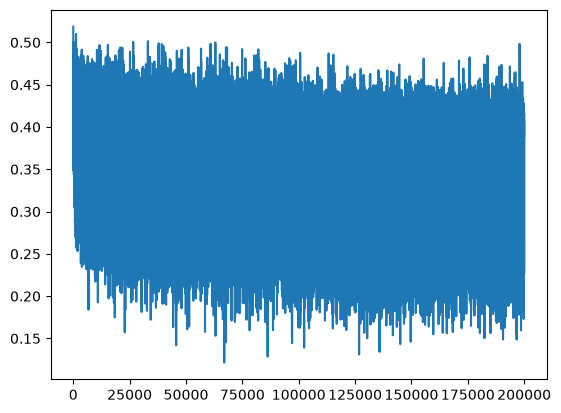

In [60]:
#而且我们会发现，刚刚我们的神经网络里涉及了mean和std，这个显然应该是训练出来的参数
#所以我们在验证集和测试集的mean和std应该沿用训练集的mean和std
#否则会导致数据泄露和真实度缺失

#先求出训练集的整体的mean和std
with torch.no_grad():
    # pass the training set through
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    # measure the mean/std over the entire training set
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)


@torch.no_grad() #关掉grad,评估的时候不需要反向传播
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]#用传入的split进行查表
    
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    hpreact=embcat@ W1 + b1
    hpreact=bngain * (hpreact - bnmean) / bnstd + bnbias 
    h = torch.tanh(hpreact) 
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

plt.plot(lossi)

In [61]:
#可以看到Xtr的loss没有变化，val的loss略有下降

In [62]:
#现在我们尝试下把刚刚学的何恺明优化和BatchNorm优化放到我们自己写的多层网络试试看

#固定参数
vocab_size=27
g = torch.Generator().manual_seed(2147483647)

#旋钮
block_size=3
n_embd=40
n_steps=100000
batch_size=64
lr1=0.1
lr2=0.03
layer=[block_size*n_embd,800,300,vocab_size]

Ws=[]
bs=[]

bngains=[]
bnbiases=[]

#超参数
C = torch.randn((vocab_size, n_embd), generator=g)#嵌入层

#神经网络层
for n1,n2 in zip(layer[:-1],layer[1:]):
    Ws.append(torch.randn((n1,n2), generator=g)*(5/3)/(n1)**0.5)#优化一下
    bs.append(torch.randn(n2,generator=g)*0.01)

for n1,n2 in zip(layer[:-2],layer[1:-1]):
    bngains.append(torch.ones((1,n2)))
    bnbiases.append(torch.zeros((1,n2)))
    
parameters = [C]+Ws+bs+bngains+bnbiases#所有的总参数，用于后续的梯度清除

print(f"总参数量：{sum(p.nelement() for p in parameters)}")


for p in parameters:
    p.requires_grad=True

lossi=[]
#训练
for i in range(n_steps):
    
    #前向传播
    ix=torch.randint(0,Xtr.shape[0],(batch_size,))
    emb = C[Xtr[ix]] 
    x = emb.view(-1, block_size * n_embd)
    for j in range(len(layer)-2):
        hpreact=x @ Ws[j] + bs[j]
        hpreact=bngains[j] * (hpreact - hpreact.mean(0,keepdim=True)) / hpreact.std(0,keepdim=True) + bnbiases[j]
        x = torch.tanh(hpreact) 
     
    logits = x @ Ws[-1] + bs[-1]                    
    loss=F.cross_entropy(logits,Ytr[ix])
    
    #清空梯度
    for p in parameters:
        p.grad=None
    
    #反向传播
    loss.backward()

    #更新梯度
    for p in parameters:
        if i < n_steps/2:   
            p.data+=-lr1*p.grad
        else:
            p.data+=-lr2*p.grad
        
    if i%10000==0:
        print(f"训练进度：{i:7d}/{n_steps:7d}:{loss.item():.4f}")
    lossi.append(loss.log10().item())

总参数量：348507
训练进度：      0/ 100000:4.0051
训练进度：  10000/ 100000:2.3770
训练进度：  20000/ 100000:2.0029
训练进度：  30000/ 100000:2.2449
训练进度：  40000/ 100000:1.7804
训练进度：  50000/ 100000:2.2038
训练进度：  60000/ 100000:2.0522
训练进度：  70000/ 100000:1.9955
训练进度：  80000/ 100000:1.9193
训练进度：  90000/ 100000:1.9319


train 1.968798279762268
val 2.0821468830108643


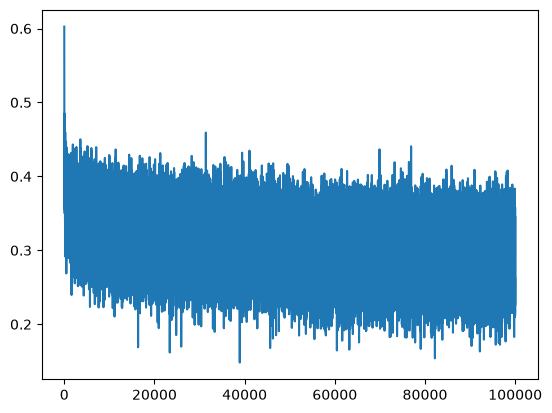

In [63]:
with torch.no_grad():
    # pass the training set through
    bnmeans=[]
    bnstds=[]
    
    emb = C[Xtr]
    x = emb.view(emb.shape[0], -1)
    for j in range(len(layer)-2):
        hpreact=x @ Ws[j] + bs[j]

        bnmeans.append(hpreact.mean(0,keepdim=True))
        bnstds.append(hpreact.std(0,keepdim=True))
        
        hpreact=bngains[j] * (hpreact - hpreact.mean(0,keepdim=True)) / hpreact.std(0,keepdim=True) + bnbiases[j]
        x = torch.tanh(hpreact) 
    # measure the mean/std over the entire training set


@torch.no_grad() #关掉grad,评估的时候不需要反向传播
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]#用传入的split进行查表

    emb = C[x] 
    x = emb.view(emb.shape[0], -1)
    for j in range(len(layer)-2):
        hpreact=x @ Ws[j] + bs[j]
        hpreact=bngains[j] * (hpreact - bnmeans[j]) / bnstds[j] + bnbiases[j]
        x = torch.tanh(hpreact) 
    logits = x @ Ws[-1] + bs[-1]                    
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

plt.plot(lossi)

In [64]:
#下降依旧很明显！

In [65]:
#接下来关于这个均值和标准差我们有一种滑动均值和滑动标准差的策略

In [66]:
g = torch.Generator().manual_seed(2147483647)

#旋钮
n_embd=10
n_hidden=200

#超参数
C = torch.randn((vocab_size, n_embd),          generator=g)          #嵌入层
W1 = torch.randn((block_size*n_embd,n_hidden), generator=g)*(5/3)/((block_size*n_embd)**0.5)      #隐藏层
b1 = torch.randn(n_hidden,                     generator=g)*0.01     #隐藏层
W2 = torch.randn((n_hidden,vocab_size),        generator=g)*0.01     #激活层
b2 = torch.randn(vocab_size,                   generator=g)*0        #激活层
#我们这里给神经网络进行缩放

#bn是BatchNorm的缩写
bngain=torch.ones((1,n_hidden))
bnbias=torch.zeros((1,n_hidden))

bnmean_running=torch.zeros((1,n_hidden))
bnstd_running=torch.ones((1,n_hidden))

parameters = [C, W1, b1, W2, b2]#所有的总参数，用于后续的梯度清除 
print(f"总参数量：{sum(p.nelement() for p in parameters)}")
for p in parameters:
    p.requires_grad=True

max_steps=200000
batch_size=32

lossi=[]

#训练
for i in range(max_steps):
    
    #前向传播
    ix=torch.randint(0,Xtr.shape[0],(batch_size,),generator=g)
    Xb,Yb=Xtr[ix],Ytr[ix]
    
    emb = C[Xb]
    embcat=emb.view(batch_size, block_size*n_embd)
    hpreact=embcat@ W1 + b1

    bnmeani=hpreact.mean(0,keepdim=True)
    bnstdi=hpreact.std(0,keepdim=True)
    
    hpreact=bngain * (hpreact - bnmeani) / bnstdi + bnbias

    with torch.no_grad():
        bnmean_running=0.999*bnmean_running+0.001*bnmeani
        bnstd_running=0.999*bnstd_running +0.001*bnstdi
   
    h = torch.tanh(hpreact) # (32, 100)
    logits = h @ W2 + b2 
    loss=F.cross_entropy(logits,Yb)
    
    #清空梯度
    for p in parameters:
        p.grad=None
    
    #反向传播
    loss.backward()

    #更新梯度
    lr=0.1 if i<(max_steps/2) else 0.01
    for p in parameters:
        p.data+=-lr*p.grad

    if i%10000==0:
        print(f"{i:7d}/{max_steps:7d}:{loss.item():.4f}")
    #存储参数
    lossi.append(loss.log10().item())

总参数量：11897
      0/ 200000:3.3014
  10000/ 200000:2.4741
  20000/ 200000:2.3700
  30000/ 200000:2.1226
  40000/ 200000:2.0765
  50000/ 200000:2.4525
  60000/ 200000:2.2495
  70000/ 200000:2.0566
  80000/ 200000:2.0036
  90000/ 200000:2.0747
 100000/ 200000:2.4734
 110000/ 200000:2.1293
 120000/ 200000:2.1174
 130000/ 200000:2.4815
 140000/ 200000:2.4186
 150000/ 200000:2.3062
 160000/ 200000:2.1342
 170000/ 200000:2.0313
 180000/ 200000:2.2986
 190000/ 200000:1.8783


In [67]:
#训练过程是一样的，但是后面我们在验证和生成的时候可以用平滑值

train 2.0746045112609863
val 2.114698886871338


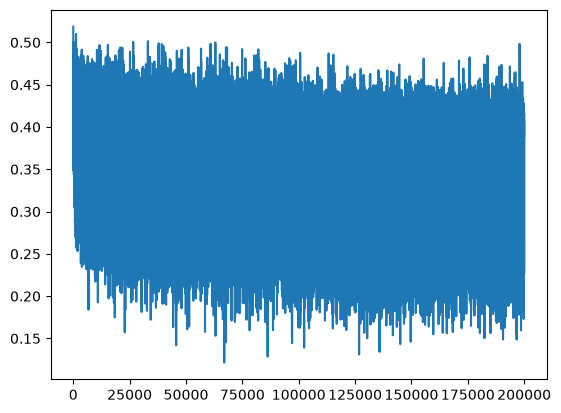

In [68]:
# with torch.no_grad():
#     # pass the training set through
#     emb = C[Xtr]
#     embcat = emb.view(emb.shape[0], -1)
#     hpreact = embcat @ W1 + b1
#     # measure the mean/std over the entire training set
#     bnmean = hpreact.mean(0, keepdim=True)
#     bnstd = hpreact.std(0, keepdim=True)


@torch.no_grad() #关掉grad,评估的时候不需要反向传播
def split_loss(split):
    x,y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]#用传入的split进行查表
    
    emb = C[x]
    embcat = emb.view(emb.shape[0], -1)
    hpreact=embcat@ W1 + b1
    hpreact=bngain * (hpreact - bnmean_running) / bnstd_running + bnbias 
    h = torch.tanh(hpreact) 
    logits = h @ W2 + b2 
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

plt.plot(lossi)

In [69]:
with torch.no_grad():
    # pass the training set through
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1
    # measure the mean/std over the entire training set
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)

bnmean,bnmean_running

(tensor([[-2.5657, -0.0334, -1.0148,  2.6168,  1.2250,  0.4890,  1.7342, -0.3011,
           1.1920,  1.3556, -1.7162, -1.4035, -1.3000, -0.1375, -1.1917, -0.5158,
           0.1782, -1.6138, -1.0287,  1.1258, -0.5784, -0.1577, -0.3232,  0.5141,
           0.8981,  1.7847,  1.0183, -0.5649,  1.2393,  1.8736,  0.3631, -0.5971,
           0.3327,  0.1922,  0.7534, -0.4854, -1.5403,  0.7817,  0.3533,  0.7622,
           0.1787, -1.2963, -0.6000,  0.3155,  1.2259,  0.1580,  1.2183, -1.0127,
           1.5100,  0.8114,  0.1573, -0.0398,  2.0487,  0.6072,  0.9317, -1.5106,
           0.0141,  0.0362,  2.5221, -2.1563, -0.0128,  0.3923,  0.1609,  1.2093,
           1.2442,  0.7855, -0.1590,  1.6851, -0.5332, -0.8752, -0.2124,  1.0618,
           0.4443, -1.9611, -1.7577, -0.1436,  1.4405,  0.9187, -0.9862,  0.7661,
          -0.0401,  1.3318,  1.0793,  0.8638,  0.3015,  0.5849, -0.4621,  0.3453,
           0.5477, -0.1333, -0.7808,  1.8053,  0.0778, -1.3920, -1.9423,  1.1381,
          -0.988

In [70]:
#可以看到这个running和整体的其实区别不大
#这个running的主要作用其实只是为了在验证和测试的时候提供一个训练过程产出的mean和std

In [71]:
#其实makemore part3的逻辑部分这个时候已经结束了
#但考虑到我们现在已经学习了不少的神经网络的知识
#andrej此时开始带我们实现标准化的模型，而不是像手工作坊一样的一行行硬敲

In [72]:
#首先我们来创建神经网络最重要的线性层
#也就是x@w+b
#torch.nn.Linear已经实现过这个了
#现在我们来重新实现简化的linear层

class Linear:
    def __init__(self, fan_in, fan_out, bias=True):#这里给出了是否使用偏置项的选项
        #fan_in和fan_out是扇入和扇出，也就是矩阵的行数和列数
        #也就是输入特征数量和输出特征数量
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5#使用了何恺明初始化法，gain默认为1
        #这里的generator=g后续会调用全局变量g
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        #可以直接(x)调用乘法
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

In [73]:
#来实现批量归一化的层
#同样是pytorch的简化实现
#默认了数据类型是float32，设备是cpu

class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1): 
        #dim是维度数
        #eps是用于除法的极小值
        #momentum是跟踪滑动统计量
        
        self.eps = eps
        self.momentum = momentum
        self.training = True

        #这两个就是之前的bngain和bnbias
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)

        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # calculate the forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True) # batch mean
            xvar = x.var(0, keepdim=True) # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) #这里相比较之前除法多了一个eps防止除0
        self.out = self.gamma * xhat + self.beta
        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

In [74]:
#tanh非常简单，就是一个单纯的计算
#但是要注意哦！虽然只是一个计算，但它本质也是一个层
#我们之前其实默认：一层线性，一层tanh，一层线性，一层tanh......
#所以之前我们的简易多层神经网络其实是不完善的，或者说我们所写的那个layer其实不是标准写法
#仅仅用几个数字标记了每一层的数量，并没有真正的实现神经网络的复杂性
class Tanh:
    def __call__(self,x):
       self.out=torch.tanh(x)
       return self.out
    def parameters(self):
        return []

In [75]:
n_embed=10
n_hidden=100
g=torch.Generator().manual_seed(2147483647)

C=torch.randn((vocab_size,n_embed),generator=g)#嵌入层

#接下来我们可以用列表的形式来实现神经网络层
#就像搭积木一样
layers=[
    Linear(n_embed*block_size,n_hidden), Tanh(),
    Linear(n_hidden,n_hidden          ), Tanh(),
    Linear(n_hidden,n_hidden          ), Tanh(),
    Linear(n_hidden,n_hidden          ), Tanh(),
    Linear(n_hidden,n_hidden          ), Tanh(),
    Linear(n_hidden,vocab_size        )
]

In [76]:
with torch.no_grad():
    layers[-1].weight *= 0.1 #最后一层的weight减小，让logits比较小，使得一开始的logits不会过于自信

    for layer in layers[:-1]:
        if isinstance(layer,Linear):
            layer.weight*=(5/3)
    #tanh的gain增益函数    

In [77]:
#总参数，并设置梯度
parameters=[C]+[p for layer in layers for p in layer.parameters()]
print("参数总量：",sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad=True

参数总量： 46497


In [78]:
max_steps=20000
batch_size=32
lossi=[]

for i in range(max_steps):

    #batch
    ix = torch.randint(0,Xtr.shape[0],(batch_size,),generator=g)
    Xb,Yb=Xtr[ix],Ytr[ix]

    #前向传播
    emb=C[Xb]
    x=emb.view(emb.shape[0],-1)
    for layer in layers:
        x=layer(x)
    loss=F.cross_entropy(x,Yb)

    #让每一层的out的grad保留下来
    for layer in layers:
        layer.out.retain_grad()

    #清空梯度
    for p in parameters:
        p.grad=None

    #反向传播
    loss.backward()

    #更新
    lr = 0.1 if i < max_steps/2 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i%10000==0:
        print(f"{i:7d}/{max_steps:7d}:{loss.item():.4f}")

    lossi.append(loss.log10().item())

    break

      0/  20000:3.3245


layer 1 (      Tanh): mean -0.05, std 0.77, saturated: 22.25%
layer 3 (      Tanh): mean +0.00, std 0.69, saturated: 10.50%
layer 5 (      Tanh): mean +0.02, std 0.67, saturated: 7.25%
layer 7 (      Tanh): mean -0.01, std 0.65, saturated: 5.06%
layer 9 (      Tanh): mean -0.01, std 0.65, saturated: 6.37%


Text(0.5, 1.0, 'activation distribution')

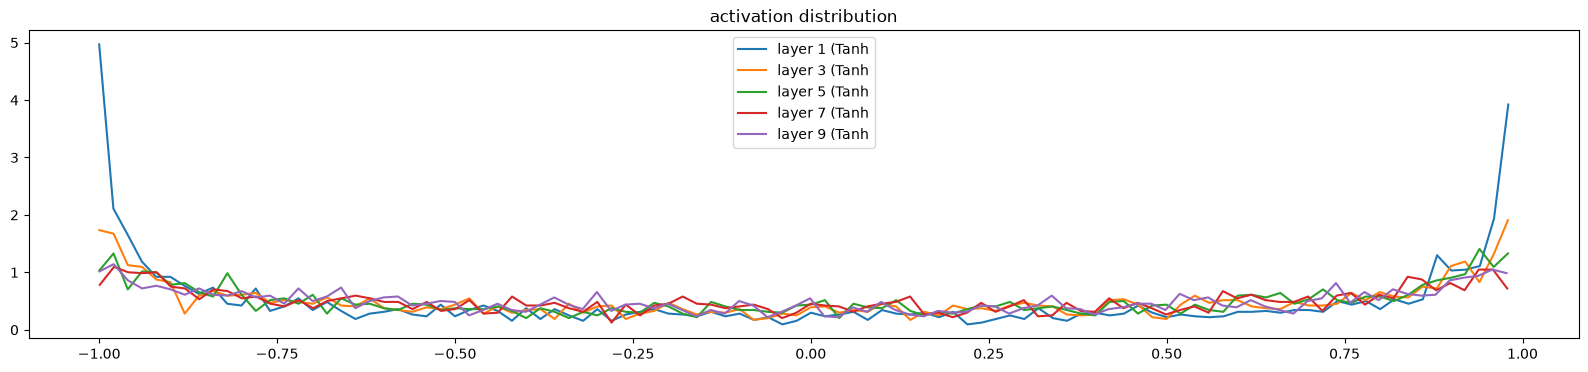

In [79]:
#这一段代码是一段可视化代码
#用于展示最后一次训练结束后每一个tanh层激活出来的值的分布
#这个图其实是直方折线图
#横轴是一格一格
#每一格代表了在这个范围内的激活值
#纵轴代表了占比
#比如说layer1
#可以看到在靠近-1和1的地方密度比较大（tanh在0～1）
#代表layer1的激活值有不少是饱和的
#从上方的统计也可以看到，layer1有20%多的饱和率

#其实纵轴的真实数学意义是 占比/每一格的宽度
#这样的统计图绘制方法在高中数学阶段的概率统计部分应当学习过

#注意此刻我们只进行了一轮，基本可以认为就是初始化

# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean().item(), t.std().item(), ((t.abs() > 0.97).float().mean().item()*100)))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

In [80]:
#可以发现只有layer1的有比较大的波动
#其他层都蛮稳定的
#这说明我们的大部分层都分布的很均匀
#这和我们采用的何恺明初始化法有关

layer 1 (      Tanh): mean -0.00, std 0.00, saturated: 0.00%
layer 3 (      Tanh): mean -0.00, std 0.00, saturated: 0.00%
layer 5 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%
layer 7 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%
layer 9 (      Tanh): mean -0.00, std 0.00, saturated: 0.00%


Text(0.5, 1.0, 'gradient distribution')

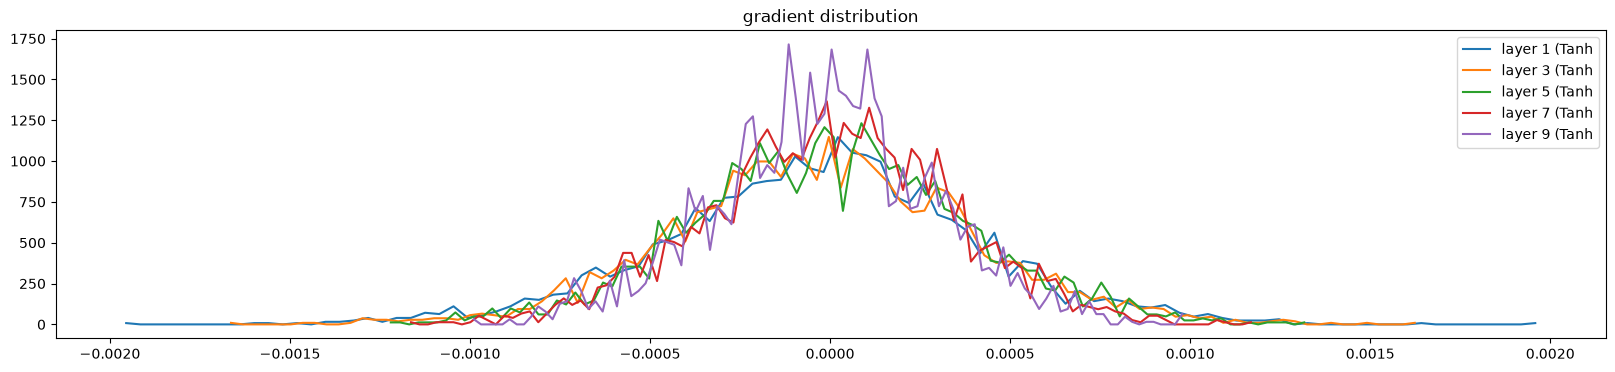

In [81]:
#同样的，我们也可以看看grad是怎么变的

# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean().item(), t.std().item(), ((t.abs() > 0.97).float().mean().item()*100)))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

In [82]:
#可以看到grad也比较合适，没有太大也没有全部都很小

In [83]:
#我们来看看如果没有用何恺明的增益函数gain会怎么样

n_embed=10
n_hidden=100
g=torch.Generator().manual_seed(2147483647)

C=torch.randn((vocab_size,n_embed),generator=g)

layers=[
    Linear(n_embed*block_size,n_hidden), Tanh(),
    Linear(n_hidden,n_hidden          ), Tanh(),
    Linear(n_hidden,n_hidden          ), Tanh(),
    Linear(n_hidden,n_hidden          ), Tanh(),
    Linear(n_hidden,n_hidden          ), Tanh(),
    Linear(n_hidden,vocab_size        )
]

with torch.no_grad():
    layers[-1].weight *= 0.1 

    for layer in layers[:-1]:
        if isinstance(layer,Linear):
            layer.weight*=1 #(5/3)
    #设为1而不是5/3

parameters=[C]+[p for layer in layers for p in layer.parameters()]
print("参数总量：",sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad=True

max_steps=20000
batch_size=32
lossi=[]

for i in range(max_steps):

    #batch
    ix = torch.randint(0,Xtr.shape[0],(batch_size,),generator=g)
    Xb,Yb=Xtr[ix],Ytr[ix]

    #前向传播
    emb=C[Xb]
    x=emb.view(emb.shape[0],-1)
    for layer in layers:
        x=layer(x)
    loss=F.cross_entropy(x,Yb)

    #让每一层的out的grad保留下来
    for layer in layers:
        layer.out.retain_grad()

    #清空梯度
    for p in parameters:
        p.grad=None

    #反向传播
    loss.backward()

    #更新
    lr = 0.1 if i < max_steps/2 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i%10000==0:
        print(f"{i:7d}/{max_steps:7d}:{loss.item():.4f}")

    lossi.append(loss.log10().item())

    break

参数总量： 46497
      0/  20000:3.3073


layer 1 (      Tanh): mean -0.04, std 0.64, saturated: 4.63%
layer 3 (      Tanh): mean -0.00, std 0.49, saturated: 0.03%
layer 5 (      Tanh): mean +0.01, std 0.41, saturated: 0.00%
layer 7 (      Tanh): mean -0.00, std 0.35, saturated: 0.00%
layer 9 (      Tanh): mean -0.01, std 0.32, saturated: 0.00%
layer 1 (      Tanh): mean -0.00, std 0.00, saturated: 0.00%
layer 3 (      Tanh): mean -0.00, std 0.00, saturated: 0.00%
layer 5 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%
layer 7 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%
layer 9 (      Tanh): mean -0.00, std 0.00, saturated: 0.00%


Text(0.5, 1.0, 'gradient distribution')

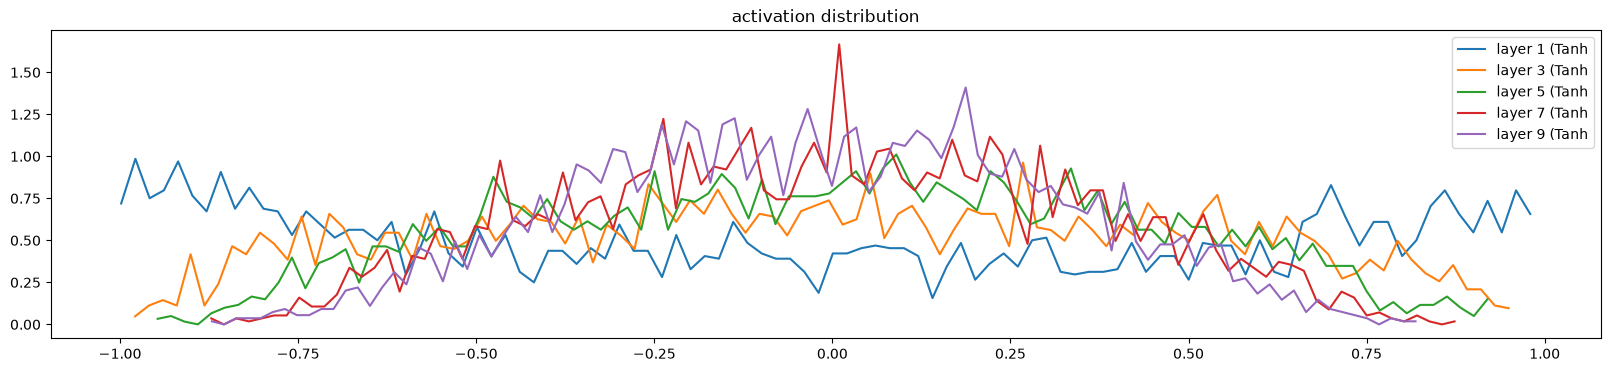

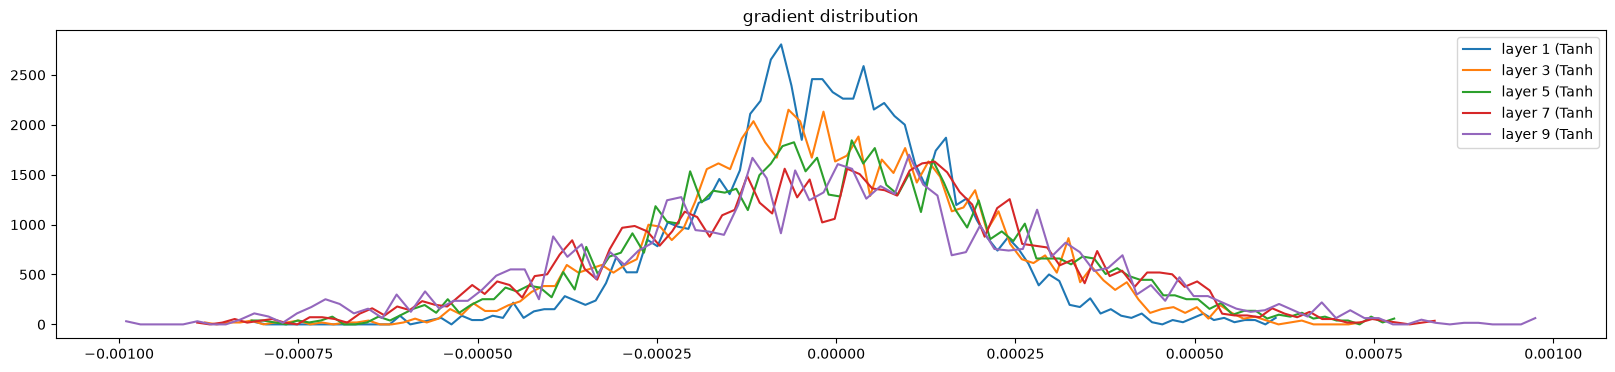

In [84]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean().item(), t.std().item(), ((t.abs() > 0.97).float().mean().item()*100)))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean().item(), t.std().item(), ((t.abs() > 0.97).float().mean().item()*100)))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

In [85]:
#激活值的波动非常剧烈
#并且可以看到layer越深越往中间聚拢
#这是因为失去了gain之后，激活值会偏小，于是就会往0靠拢
#每加深一层就会再靠拢一些

#同样注意grad的横轴变化之后可以发现grad是在往两边扩散的
#因为激活值变小，靠近0会导致tanh的grad放大

In [86]:
#如果这个gain过大
#我们来看看如果没有用何恺明的增益函数gain会怎么样

n_embed=10
n_hidden=100
g=torch.Generator().manual_seed(2147483647)

C=torch.randn((vocab_size,n_embed),generator=g)

layers=[
    Linear(n_embed*block_size,n_hidden), Tanh(),
    Linear(n_hidden,n_hidden          ), Tanh(),
    Linear(n_hidden,n_hidden          ), Tanh(),
    Linear(n_hidden,n_hidden          ), Tanh(),
    Linear(n_hidden,n_hidden          ), Tanh(),
    Linear(n_hidden,vocab_size        )
]

with torch.no_grad():
    layers[-1].weight *= 0.1 

    for layer in layers[:-1]:
        if isinstance(layer,Linear):
            layer.weight*=3 #(5/3)
    #gain过大

parameters=[C]+[p for layer in layers for p in layer.parameters()]
print("参数总量：",sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad=True

max_steps=20000
batch_size=32
lossi=[]

for i in range(max_steps):

    #batch
    ix = torch.randint(0,Xtr.shape[0],(batch_size,),generator=g)
    Xb,Yb=Xtr[ix],Ytr[ix]

    #前向传播
    emb=C[Xb]
    x=emb.view(emb.shape[0],-1)
    for layer in layers:
        x=layer(x)
    loss=F.cross_entropy(x,Yb)

    #让每一层的out的grad保留下来
    for layer in layers:
        layer.out.retain_grad()

    #清空梯度
    for p in parameters:
        p.grad=None

    #反向传播
    loss.backward()

    #更新
    lr = 0.1 if i < max_steps/2 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i%10000==0:
        print(f"{i:7d}/{max_steps:7d}:{loss.item():.4f}")

    lossi.append(loss.log10().item())

    break

参数总量： 46497
      0/  20000:3.3328


layer 1 (      Tanh): mean -0.06, std 0.86, saturated: 51.13%
layer 3 (      Tanh): mean +0.01, std 0.84, saturated: 41.84%
layer 5 (      Tanh): mean +0.03, std 0.84, saturated: 42.34%
layer 7 (      Tanh): mean +0.00, std 0.83, saturated: 40.25%
layer 9 (      Tanh): mean -0.02, std 0.84, saturated: 39.84%
layer 1 (      Tanh): mean -0.00, std 0.00, saturated: 0.00%
layer 3 (      Tanh): mean -0.00, std 0.00, saturated: 0.00%
layer 5 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%
layer 7 (      Tanh): mean +0.00, std 0.00, saturated: 0.00%
layer 9 (      Tanh): mean -0.00, std 0.00, saturated: 0.00%


Text(0.5, 1.0, 'gradient distribution')

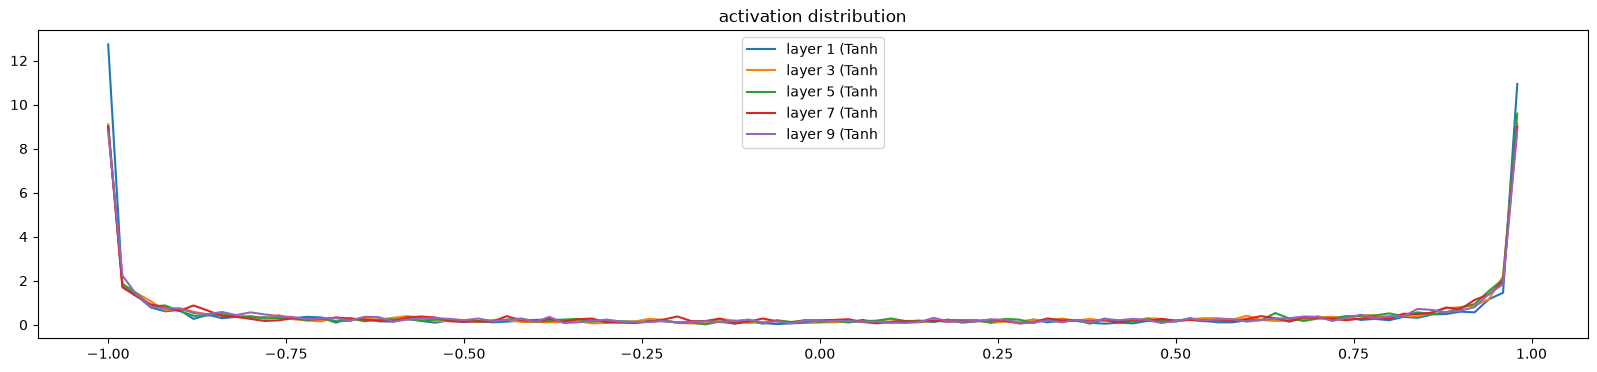

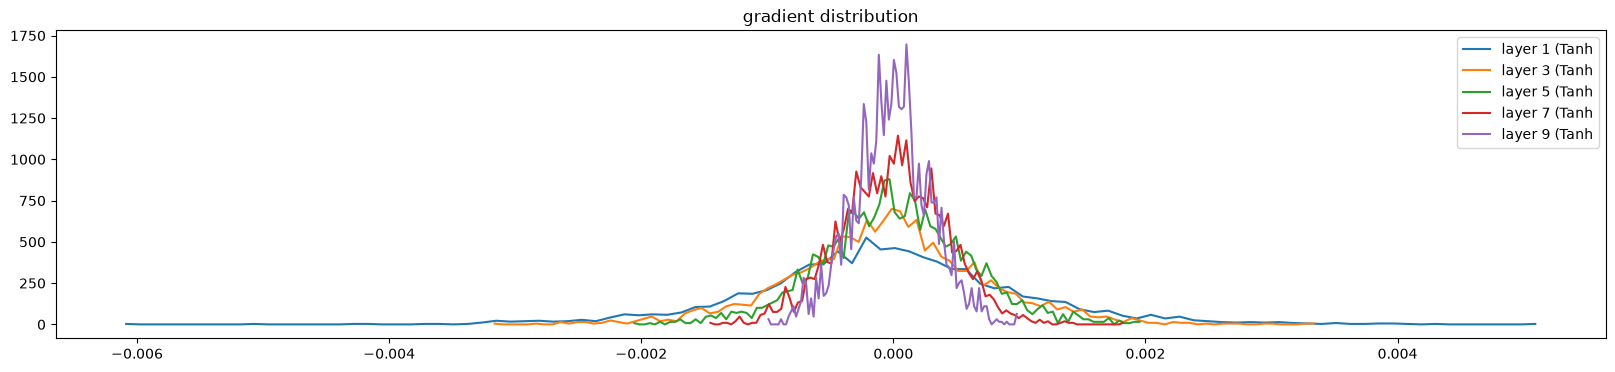

In [87]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean().item(), t.std().item(), ((t.abs() > 0.97).float().mean().item()*100)))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean().item(), t.std().item(), ((t.abs() > 0.97).float().mean().item()*100)))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

In [88]:
#可以看到饱和率非常高
#并且grad大量的集中在0
#这是完全失败的

In [89]:
#换回处理好的版本
n_embed=10
n_hidden=100
g=torch.Generator().manual_seed(2147483647)

C=torch.randn((vocab_size,n_embed),generator=g)

layers=[
    Linear(n_embed*block_size,n_hidden), Tanh(),
    Linear(n_hidden,n_hidden          ), Tanh(),
    Linear(n_hidden,n_hidden          ), Tanh(),
    Linear(n_hidden,n_hidden          ), Tanh(),
    Linear(n_hidden,n_hidden          ), Tanh(),
    Linear(n_hidden,vocab_size        )
]

with torch.no_grad():
    layers[-1].weight *= 0.1 

    for layer in layers[:-1]:
        if isinstance(layer,Linear):
            layer.weight*=(5/3)

parameters=[C]+[p for layer in layers for p in layer.parameters()]
print("参数总量：",sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad=True

max_steps=20000
batch_size=32
lossi=[]

for i in range(max_steps):

    #batch
    ix = torch.randint(0,Xtr.shape[0],(batch_size,),generator=g)
    Xb,Yb=Xtr[ix],Ytr[ix]

    #前向传播
    emb=C[Xb]
    x=emb.view(emb.shape[0],-1)
    for layer in layers:
        x=layer(x)
    loss=F.cross_entropy(x,Yb)

    #让每一层的out的grad保留下来
    for layer in layers:
        layer.out.retain_grad()

    #清空梯度
    for p in parameters:
        p.grad=None

    #反向传播
    loss.backward()

    #更新
    lr = 0.1 if i < max_steps/2 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i%10000==0:
        print(f"{i:7d}/{max_steps:7d}:{loss.item():.4f}")

    lossi.append(loss.log10().item())

    break

参数总量： 46497
      0/  20000:3.3245


weight   (27, 10) | mean -0.000115 ｜ std 1.313972e-03 | grad:data ratio 1.313018e-03


/var/folders/bj/h9w4f26d58vc04wvwhk6kd580000gn/T/ipykernel_29574/4271944651.py:9: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:823.)
  print('weight %10s | mean %+f ｜ std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std()/p.std()))


weight  (30, 100) | mean +0.000022 ｜ std 1.445268e-03 | grad:data ratio 4.634284e-03
weight (100, 100) | mean -0.000012 ｜ std 1.152157e-03 | grad:data ratio 6.935685e-03
weight (100, 100) | mean -0.000023 ｜ std 9.818746e-04 | grad:data ratio 5.848540e-03
weight (100, 100) | mean +0.000006 ｜ std 8.229408e-04 | grad:data ratio 4.922444e-03
weight (100, 100) | mean +0.000011 ｜ std 7.531863e-04 | grad:data ratio 4.500858e-03
weight  (100, 27) | mean +0.000000 ｜ std 2.274057e-02 | grad:data ratio 2.266734e+00


Text(0.5, 1.0, 'weight gradient distribution')

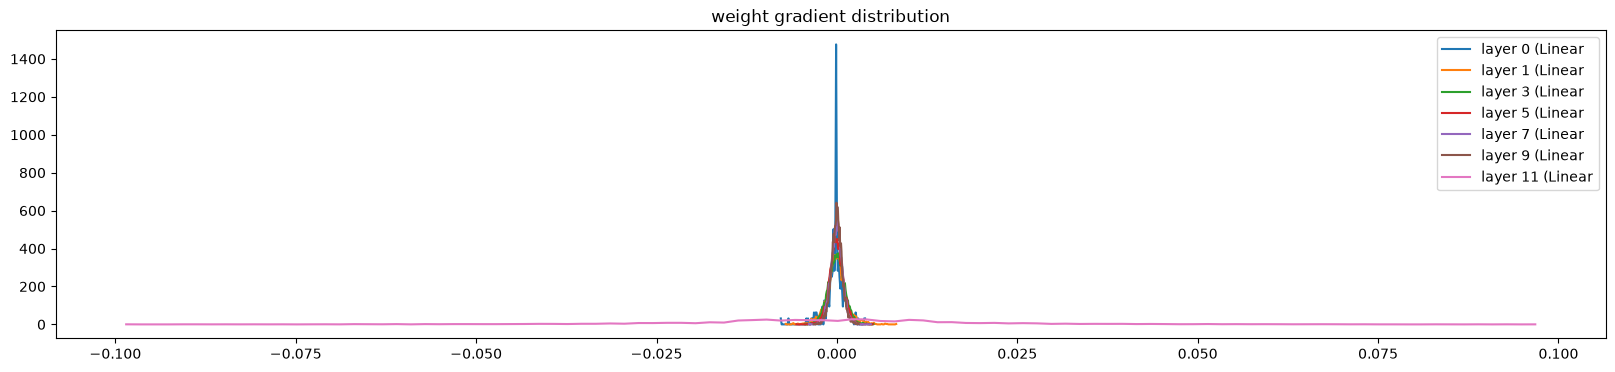

In [90]:
#接下来我们用图示法再来看看神经网络里真正重要的东西：参数的grad

# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, p in enumerate(parameters): # note: exclude the output layer  
    t = p.grad
    if p.ndim==2:#选取dim是2的参数，这样的话基本只选到了weight参数，而bias，gamma，beta等基本不会进来
        print('weight %10s | mean %+f ｜ std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std()/p.std()))
        hy, hx = torch.histogram(t, density=True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('weight gradient distribution')

In [91]:
#这里有个比较有意思的值：grad:data
#grad和data的比值可以反映：当前的模型会怎么进一步变化
#如果这个比值过大的话，可能就会导致这个data会有比较大的波动，不太好。

In [92]:
#但其实有个更好的去看模型变化幅度是否合适的值：调整值：data
#也就是grad*lr:data
#接下来就是新建一个列表来存储这个比值在训练中的变化

In [93]:
n_embed=10
n_hidden=100
g=torch.Generator().manual_seed(2147483647)

C=torch.randn((vocab_size,n_embed),generator=g)

layers=[
    Linear(n_embed*block_size,n_hidden), Tanh(),
    Linear(n_hidden,n_hidden          ), Tanh(),
    Linear(n_hidden,n_hidden          ), Tanh(),
    Linear(n_hidden,n_hidden          ), Tanh(),
    Linear(n_hidden,n_hidden          ), Tanh(),
    Linear(n_hidden,vocab_size        )
]

with torch.no_grad():
    layers[-1].weight *= 0.1 

    for layer in layers[:-1]:
        if isinstance(layer,Linear):
            layer.weight*=(5/3)

parameters=[C]+[p for layer in layers for p in layer.parameters()]
print("参数总量：",sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad=True

max_steps=20000
batch_size=32
lossi=[]

ud=[]

for i in range(max_steps):

    #batch
    ix = torch.randint(0,Xtr.shape[0],(batch_size,),generator=g)
    Xb,Yb=Xtr[ix],Ytr[ix]

    #前向传播
    emb=C[Xb]
    x=emb.view(emb.shape[0],-1)
    for layer in layers:
        x=layer(x)
    loss=F.cross_entropy(x,Yb)

    #让每一层的out的grad保留下来
    for layer in layers:
        layer.out.retain_grad()

    #清空梯度
    for p in parameters:
        p.grad=None

    #反向传播
    loss.backward()

    #更新
    lr = 0.1 if i < max_steps/2 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i%10000==0:
        print(f"{i:7d}/{max_steps:7d}:{loss.item():.4f}")

    lossi.append(loss.log10().item())

    with torch.no_grad():
        ud.append([(lr*p.grad.std()/p.data.std()).log10().item() for p in parameters])

    #存储grad*lr的std的比值
    #因为这些值有正有负，所以直接用mean不好
    #采用std会更直观

    if i > 1000:
        break

参数总量： 46497
      0/  20000:3.3245


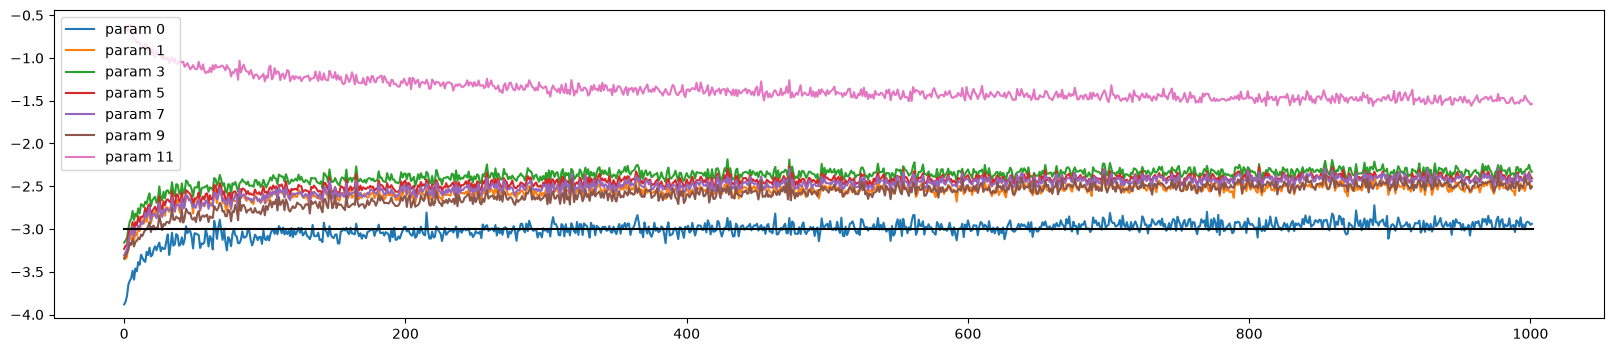

In [94]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot( [ud[j][i] for j in range(len(ud))] )
    legends.append('param %d' % i)
plt.plot( [0, len(ud)], [-3, -3], 'k' ) # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);


In [95]:
#我们可以看到图里面有一条黑色的水平线
#这是andrej设置的参考线
#因为我们希望这个值大致要落到这个区间附近
#可以看到我们现在落的不错
#因为我们的初始化和学习率设置的都不错

#我们来看看如果学习率特别低会怎么样

In [96]:
n_embed=10
n_hidden=100
g=torch.Generator().manual_seed(2147483647)

C=torch.randn((vocab_size,n_embed),generator=g)

layers=[
    Linear(n_embed*block_size,n_hidden), Tanh(),
    Linear(n_hidden,n_hidden          ), Tanh(),
    Linear(n_hidden,n_hidden          ), Tanh(),
    Linear(n_hidden,n_hidden          ), Tanh(),
    Linear(n_hidden,n_hidden          ), Tanh(),
    Linear(n_hidden,vocab_size        )
]

with torch.no_grad():
    layers[-1].weight *= 0.1 

    for layer in layers[:-1]:
        if isinstance(layer,Linear):
            layer.weight*=(5/3)

parameters=[C]+[p for layer in layers for p in layer.parameters()]
print("参数总量：",sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad=True

max_steps=20000
batch_size=32
lossi=[]

ud=[]

for i in range(max_steps):

    #batch
    ix = torch.randint(0,Xtr.shape[0],(batch_size,),generator=g)
    Xb,Yb=Xtr[ix],Ytr[ix]

    #前向传播
    emb=C[Xb]
    x=emb.view(emb.shape[0],-1)
    for layer in layers:
        x=layer(x)
    loss=F.cross_entropy(x,Yb)

    #让每一层的out的grad保留下来
    for layer in layers:
        layer.out.retain_grad()

    #清空梯度
    for p in parameters:
        p.grad=None

    #反向传播
    loss.backward()

    #更新
    #学习率设置的很低
    lr = 0.0001 if i < max_steps/2 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    if i%10000==0:
        print(f"{i:7d}/{max_steps:7d}:{loss.item():.4f}")

    lossi.append(loss.log10().item())

    with torch.no_grad():
        ud.append([(lr*p.grad.std()/p.data.std()).log10().item() for p in parameters])

    #存储grad*lr的std的比值
    #因为这些值有正有负，所以直接用mean不好
    #采用std会更直观

    if i > 1000:
        break

参数总量： 46497
      0/  20000:3.3245


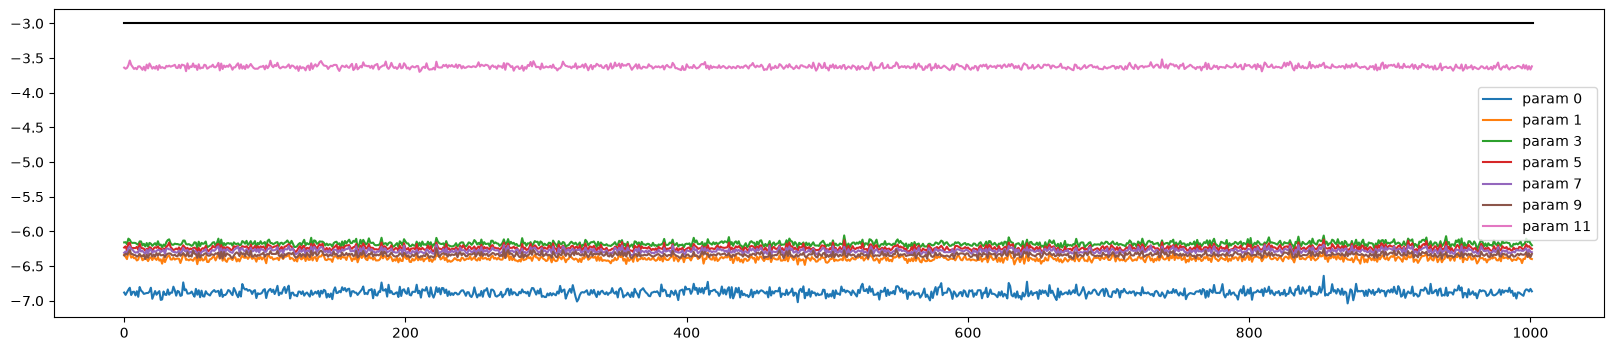

In [97]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot( [ud[j][i] for j in range(len(ud))] )
    legends.append('param %d' % i)
plt.plot( [0, len(ud)], [-3, -3], 'k' ) # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);


In [98]:
#可以看到我们的比值离10^-3非常远
#基本就是10^-6左右了
#说明我们的学习率设置的不好
#同样，如果初始化没设置好也会导致很多问题
#主要是出现不稳定的现象等等